  <div class="alert alert-info">
  Hi Yaroslav! My name is Svetlana Chikh and I will be reviewing your project. My main goal is not to point out the mistakes you have made, but to share my experience and help you. I suggest we keep things informal and use first names. But if that is not comfortable for you, let me know and we will switch to a more formal tone.

  <div class="alert alert-success">
  <b>👍 Success:</b> Green marks the successful and elegant solutions that you can build on in future projects.
  </div>
  <div class="alert alert-warning">
  <b>🤔 Recommendation:</b> Yellow highlights things that could be done differently next time. You can take these comments into account in future assignments or revise the project now (though this is not mandatory).
  </div>
  <div class="alert alert-danger">
  <b>😔 Needs fixing:</b> Red highlights the comments that I cannot accept the project without :(
  </div>
  <div class="alert alert-info">
  <b>👂 Tip:</b> Some additional materials
  </div>
  Let's work on the project as a dialogue: if you change something in the project following my recommendations, write about it.
  It will be easier for me to track the changes if you highlight your own comments:
  <div class="alert alert-info"> <b>🎓 Student comment:</b> Like this, for example.</div>
  Please do not move, modify or delete my comments. All of this will help complete the re-review of your project faster.
   </div>

# Predicting road accidents for a car-sharing company

**Task:** assess the risk of a road accident along a selected route.  
**Target variable:** `at_fault` from the `parties` table.  
**Task type:** binary classification.

**Selection criteria:**
- we keep only parties of type `car`
- we exclude cases with `scratch` damage
- we use only complete years starting from 2012
- in the current database, after the completeness check, only the year 2012 makes it into modelling
- vehicle age is treated as a separate feature


## Environment and GPU setup

In [1]:
import sys
import gc
import re
import copy
import time
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import phik
import shap
import optuna
import scipy.sparse

from IPython.display import Markdown, display
from urllib.parse import quote_plus
from sqlalchemy import bindparam, create_engine, text, inspect
from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, cross_val_score,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    fbeta_score, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix,
)
from catboost import CatBoostClassifier
from rapidfuzz import fuzz, process

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    if torch.cuda.is_available():
        DEVICE = torch.device("cuda")
        gpu_name = torch.cuda.get_device_name(0)
        gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
        cuda_version = torch.version.cuda
    else:
        DEVICE = torch.device("cpu")
        gpu_name = None
        gpu_mem = None
        cuda_version = None
except ImportError:
    DEVICE = "cpu"
    gpu_name = None
    gpu_mem = None
    cuda_version = None

python_version = sys.version.split()[0]

<div class="alert alert-success">
<b>👍 Success:</b> The necessary libraries have been imported!
</div>

<div class="alert alert-danger">
<s><b>😔 Needs fixing:</b> All imports should be at the very beginning of the work, but clearly not all of them are here. </s>
</div>

<div class="alert alert-info"> <b>🎓 Student comment:</b> Fixed: all imports have been moved to the beginning of the notebook into a single block.</div>

## Importing the libraries

In [2]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
    }
)

MAIN_COLOR = "#2E6F95"
LIGHT_COLOR = "#A9CCE3"
DARK_COLOR = "#1B4F72"
DAMAGE_PALETTE = ["#D6EAF8", "#AED6F1", "#5DADE2", "#2E86C1", "#154360"]

feature_labels = {
    "at_fault": "At-fault party",
    "party_sobriety": "Sobriety",
    "party_drug_physical": "Physical or drug condition",
    "cellphone_in_use": "Cellphone in use",
    "insurance_premium": "Insurance premium",
    "weather_1": "Weather",
    "location_type": "Location type",
    "collision_damage": "Damage severity",
    "primary_collision_factor": "Primary factor",
    "pcf_violation_category": "Violation category",
    "type_of_collision": "Collision type",
    "road_surface": "Road surface",
    "road_condition_1": "Road condition",
    "lighting": "Lighting",
    "control_device": "Control device",
    "party_count": "Party count",
    "vehicle_type": "Vehicle type",
    "vehicle_transmission": "Transmission",
    "vehicle_age": "Vehicle age",
}

party_sobriety_labels = {
    "had not been drinking": "Had not been drinking",
    "impairment unknown": "Impairment unknown",
    "had been drinking, under influence": "Had been drinking, under influence",
    "had been drinking, impairment unknown": "Had been drinking, impairment unknown",
    "had been drinking, not under influence": "Had been drinking, not under influence",
    "not applicable": "Not applicable",
}

collision_damage_labels = {
    "fatal": "Fatal",
    "severe damage": "Severe damage",
    "middle damage": "Moderate damage",
    "small damage": "Minor damage",
    "scratch": "Scratches",
}

<div class="alert alert-danger">
<s><b>😔 Needs fixing:</b> Why explore features that cannot be used to train the models? In real life, unnecessary steps stretch out the deadline and waste resources and working time.</s>
</div>

<div class="alert alert-info"> <b>🎓 Student comment:</b> Fixed: the exploratory analysis is carried out only for the features used in modelling.</div>

## Step 1. Loading the data from the database

First we connect to PostgreSQL and check the connection. Then we go through all the main tables one by one: load them from the database, convert the column names to `snake_case`, check for exact and near duplicates, reduce memory usage and look at the descriptive statistics.

#### 1.1. Connecting to the database

In [3]:
db_config = {
    "user": "praktikum_student",
    "pwd": "Sdf4$2;d-d30pp",
    "host": "rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net",
    "port": 6432,
    "db": "data-science-vehicle-db",
}

pwd_encoded = quote_plus(db_config["pwd"])
url = (
    f"postgresql://{db_config['user']}:{pwd_encoded}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['db']}"
)

engine = create_engine(url, pool_pre_ping=True)

with engine.connect() as conn:
    connection_check = conn.execute(text("SELECT 1")).scalar()

<div class="alert alert-success">
<b>👍 Success:</b> A database connection has been created!
</div>

#### 1.2. ER diagram of the database

The schema is needed so that we can see the correct join keys straight away and avoid losing rows when merging the tables.

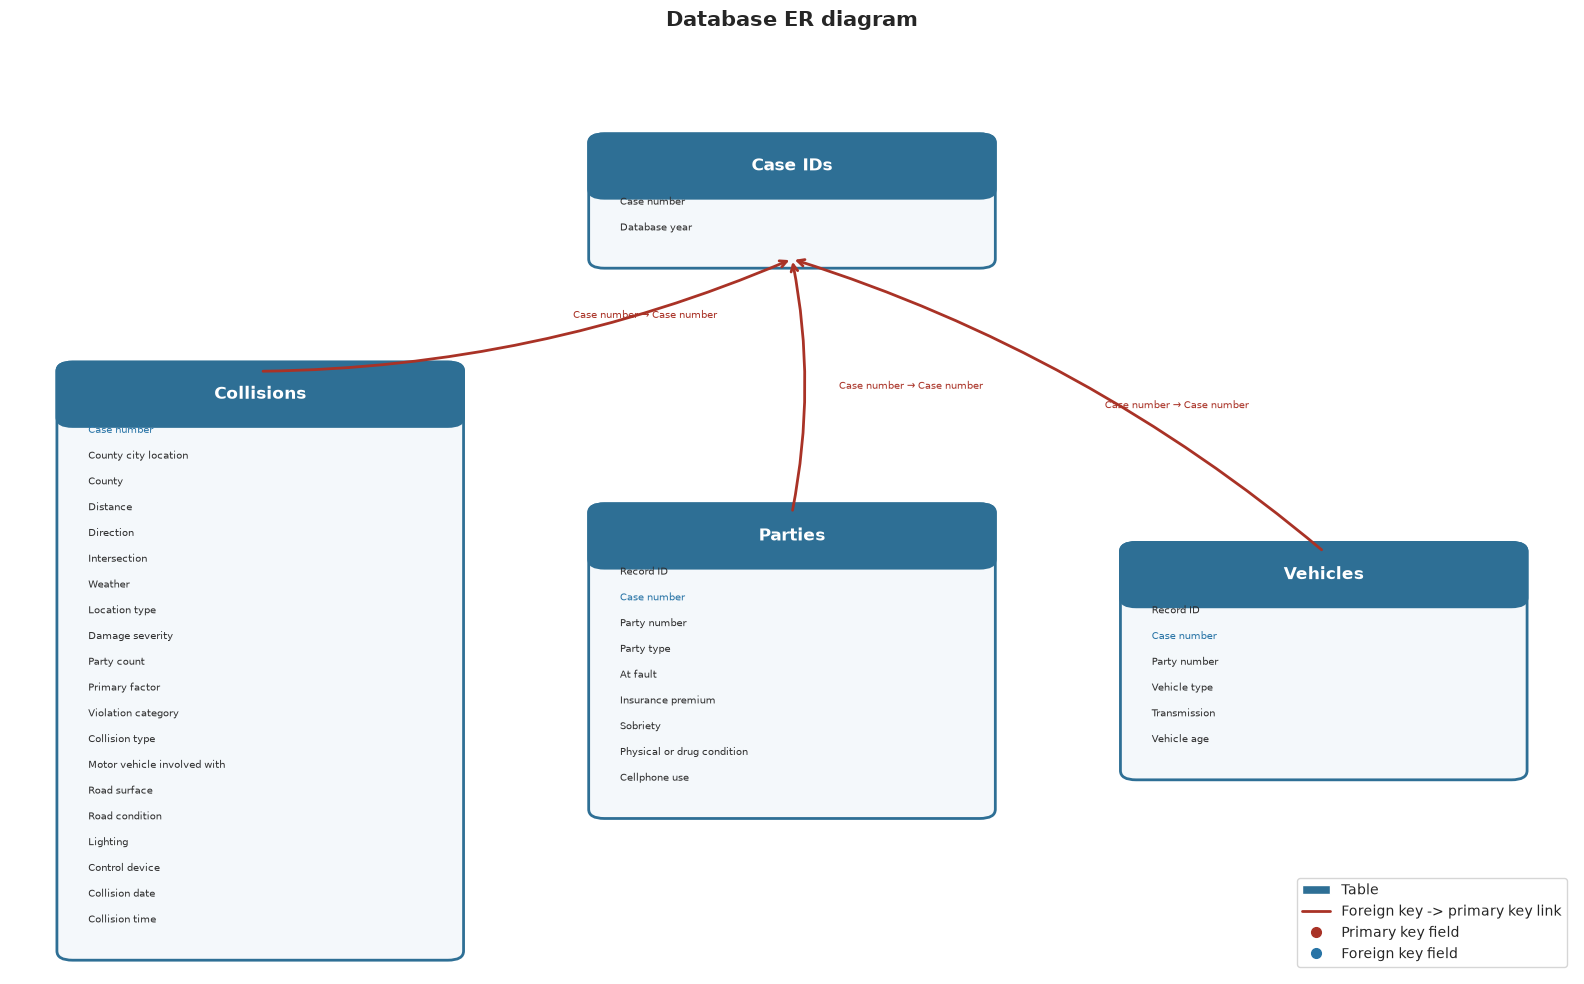

In [4]:
table_labels = {
    "case_ids": "Case IDs",
    "collisions": "Collisions",
    "parties": "Parties",
    "vehicles": "Vehicles",
}

column_labels = {
    "id": "Record ID",
    "case_id": "Case number",
    "db_year": "Database year",
    "county_city_location": "County city location",
    "county_location": "County",
    "distance": "Distance",
    "direction": "Direction",
    "intersection": "Intersection",
    "weather_1": "Weather",
    "location_type": "Location type",
    "collision_damage": "Damage severity",
    "party_count": "Party count",
    "primary_collision_factor": "Primary factor",
    "pcf_violation_category": "Violation category",
    "type_of_collision": "Collision type",
    "motor_vehicle_involved_with": "Motor vehicle involved with",
    "road_surface": "Road surface",
    "road_condition_1": "Road condition",
    "lighting": "Lighting",
    "control_device": "Control device",
    "collision_date": "Collision date",
    "collision_time": "Collision time",
    "party_number": "Party number",
    "party_type": "Party type",
    "at_fault": "At fault",
    "insurance_premium": "Insurance premium",
    "party_sobriety": "Sobriety",
    "party_drug_physical": "Physical or drug condition",
    "cellphone_in_use": "Cellphone use",
    "vehicle_type": "Vehicle type",
    "vehicle_transmission": "Transmission",
    "vehicle_age": "Vehicle age",
}

insp = inspect(engine)
tables = insp.get_table_names()
schema = {}
foreign_keys = []

for table_name in tables:
    columns = insp.get_columns(table_name)
    primary_key = insp.get_pk_constraint(table_name)
    table_foreign_keys = insp.get_foreign_keys(table_name)
    schema[table_name] = {
        "columns": [(column["name"], str(column["type"])) for column in columns],
        "pk": primary_key.get("constrained_columns", []),
    }
    for foreign_key in table_foreign_keys:
        foreign_keys.append(
            {
                "from_table": table_name,
                "from_cols": foreign_key["constrained_columns"],
                "to_table": foreign_key["referred_table"],
                "to_cols": foreign_key["referred_columns"],
            }
        )

positions = {
    "case_ids": (0.5, 0.84),
    "collisions": (0.16, 0.34),
    "parties": (0.5, 0.34),
    "vehicles": (0.84, 0.34),
}

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Database ER diagram", pad=20, fontweight="bold")

table_boxes = {}
box_width = 0.24
row_height = 0.028
header_height = 0.05

for table_name, (center_x, center_y) in positions.items():
    info = schema[table_name]
    total_height = header_height + row_height * len(info["columns"]) + 0.02
    x0 = center_x - box_width / 2
    y0 = center_y - total_height / 2

    body = FancyBboxPatch(
        (x0, y0),
        box_width,
        total_height,
        boxstyle="round,pad=0.01",
        facecolor="#F4F8FB",
        edgecolor=MAIN_COLOR,
        linewidth=2,
    )
    header = FancyBboxPatch(
        (x0, y0 + total_height - header_height),
        box_width,
        header_height,
        boxstyle="round,pad=0.01",
        facecolor=MAIN_COLOR,
        edgecolor=MAIN_COLOR,
        linewidth=2,
    )
    ax.add_patch(body)
    ax.add_patch(header)
    ax.text(
        center_x,
        y0 + total_height - header_height / 2,
        table_labels.get(table_name, table_name),
        ha="center",
        va="center",
        fontsize=12,
        color="white",
        fontweight="bold",
    )

    foreign_key_columns = set()
    for foreign_key in foreign_keys:
        if foreign_key["from_table"] == table_name:
            foreign_key_columns.update(foreign_key["from_cols"])

    for row_number, (column_name, column_type) in enumerate(info["columns"]):
        row_y = y0 + total_height - header_height - row_height * (row_number + 1)
        color = "#2F2F2F"
        if column_name in info["pk"]:
            color = "#A93226"
        elif column_name in foreign_key_columns:
            color = "#2874A6"
        label = column_labels.get(column_name, column_name)
        ax.text(
            x0 + 0.01,
            row_y + row_height / 2,
            label,
            ha="left",
            va="center",
            fontsize=7.5,
            color=color,
        )

    table_boxes[table_name] = {
        "x0": x0,
        "y0": y0,
        "w": box_width,
        "h": total_height,
        "cx": center_x,
        "cy": center_y,
    }

for foreign_key in foreign_keys:
    source = table_boxes[foreign_key["from_table"]]
    target = table_boxes[foreign_key["to_table"]]
    ax.annotate(
        "",
        xy=(target["cx"], target["y0"]),
        xytext=(source["cx"], source["y0"] + source["h"]),
        arrowprops=dict(
            arrowstyle="->",
            color="#A93226",
            lw=2,
            connectionstyle="arc3,rad=0.1",
        ),
    )
    from_label = ", ".join(column_labels.get(col, col) for col in foreign_key["from_cols"])
    to_label = ", ".join(column_labels.get(col, col) for col in foreign_key["to_cols"])
    ax.text(
        (source["cx"] + target["cx"]) / 2 + 0.03,
        (source["y0"] + source["h"] + target["y0"]) / 2,
        f"{from_label} → {to_label}",
        fontsize=7,
        color="#A93226",
        ha="left",
        va="center",
    )

legend_elements = [
    mpatches.Patch(facecolor=MAIN_COLOR, label="Table"),
    plt.Line2D([0], [0], color="#A93226", lw=2, label="Foreign key -> primary key link"),
    plt.Line2D([0], [0], color="#A93226", marker="o", lw=0, markersize=7, label="Primary key field"),
    plt.Line2D([0], [0], color="#2874A6", marker="o", lw=0, markersize=7, label="Foreign key field"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.savefig("er_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

The diagram shows that `case_id` is the central key of the database, and that linking parties to vehicles additionally requires `party_number`. The main observation is that a plain join on `case_id` is not enough: it produces duplicated rows and distorted frequencies. For the project this means that every join has to be checked for duplicates right after loading and again after the tables are merged.

## Step 2. Initial exploration of the tables

#### 2.1. Data availability and the number of tables

We inspect the tables with SQL queries: we count the rows and look at the columns of each table without loading the data into memory in full.

In [5]:
# Check that the data is present and inspect the table structure via SQL
with engine.connect() as conn:
    for table_name in ['case_ids', 'collisions', 'parties', 'vehicles']:
        row_count = conn.execute(text(f"SELECT COUNT(*) FROM {table_name}")).scalar()
        cols_query = f"""
            SELECT column_name, data_type
            FROM information_schema.columns
            WHERE table_name = '{table_name}'
            ORDER BY ordinal_position
        """
        cols_df = pd.read_sql(text(cols_query), conn)
        display(Markdown(f"**Table `{table_name}`: {row_count:,} rows, {len(cols_df)} columns**".replace(",", " ")))
        display(cols_df)

**Table `case_ids`: 1 400 000 rows  2 columns**

,column_name,data_type
0,case_id,text
1,db_year,text


**Table `collisions`: 1 400 000 rows  20 columns**

,column_name,data_type
0,case_id,text
1,county_city_location,text
2,county_location,text
3,distance,real
4,direction,text
5,intersection,integer
6,weather_1,text
7,location_type,text
8,collision_damage,text
9,party_count,integer


**Table `parties`: 2 752 408 rows  9 columns**

,column_name,data_type
0,id,integer
1,case_id,text
2,party_number,integer
3,party_type,text
4,at_fault,integer
5,insurance_premium,integer
6,party_sobriety,text
7,party_drug_physical,text
8,cellphone_in_use,integer


**Table `vehicles`: 1 021 234 rows  6 columns**

,column_name,data_type
0,id,integer
1,case_id,text
2,party_number,integer
3,vehicle_type,text
4,vehicle_transmission,text
5,vehicle_age,integer


#### 2.2. The common key linking the tables

The common key is `case_id`, which is present in all four tables. To identify a party and its vehicle uniquely, `party_number` is used in addition (the link between `parties` and `vehicles`). The ER diagram in section 1.2 illustrates these relationships clearly.

<div class="alert alert-success">
<b>👍 Success:</b> The tables have been reviewed!
</div>

## Step 2.3. Statistical analysis of road accident factors

First we look at the overall seasonality, then we examine several specific relationships. For the analytical queries below we use direct SQL queries with JOIN.

#### 2.3.0. Checking data completeness by year

Before plotting the seasonal charts, we check whether every year contains data for all 12 months. Incomplete years would distort the averages and could lead to false conclusions.

In [6]:
analysis_start_year = 2012

query_completeness = text('''
    SELECT
        EXTRACT(YEAR FROM collision_date)::int AS year,
        EXTRACT(MONTH FROM collision_date)::int AS month,
        COUNT(*) AS accident_count
    FROM collisions
    WHERE collision_date IS NOT NULL
      AND EXTRACT(YEAR FROM collision_date)::int >= :analysis_start_year
    GROUP BY year, month
    ORDER BY year, month
''')

with engine.connect() as conn:
    year_month_counts = pd.read_sql(
        query_completeness,
        conn,
        params={'analysis_start_year': analysis_start_year},
    )

year_month_counts['year'] = year_month_counts['year'].fillna(0).astype(int)
year_month_counts['month'] = year_month_counts['month'].fillna(0).astype(int)
year_month_counts['accident_count'] = year_month_counts['accident_count'].fillna(0).astype(int)

months_index = pd.Index(range(1, 13), name='month')
year_month_matrix = (
    year_month_counts
    .pivot(index='year', columns='month', values='accident_count')
    .reindex(columns=months_index, fill_value=0)
    .fillna(0)
    .astype(int)
)

df_completeness = (
    pd.DataFrame(
        {
            'year': year_month_matrix.index,
            'months_count': year_month_matrix.gt(0).sum(axis=1).to_numpy(),
            'total_records': year_month_matrix.sum(axis=1).to_numpy(),
        }
    )
    .reset_index(drop=True)
)
df_completeness['status'] = np.where(df_completeness['months_count'] == 12, 'complete', 'incomplete')

complete_years = df_completeness.loc[df_completeness['months_count'] == 12, 'year'].tolist()
incomplete_years = df_completeness.loc[df_completeness['months_count'] < 12, 'year'].tolist()
model_years = complete_years.copy()

display(Markdown(f"**Data completeness by year, from {analysis_start_year}**"))
display(df_completeness)

if complete_years:
    display(Markdown(
        f"Complete years used for modelling: **{', '.join(map(str, complete_years))}**."
    ))
else:
    display(Markdown("No complete years found in the selected range."))

if incomplete_years:
    display(Markdown(
        f"Incomplete years: **{', '.join(map(str, incomplete_years))}** - excluded from the analysis and the modelling."
    ))


**Data completeness by year, from 2012**

,year,months_count,total_records,status
0,2012,12,154547,complete
1,2013,6,305,incomplete
2,2020,2,2,incomplete


Complete years used for modelling: **2012**.

Incomplete years: **2013, 2020** - excluded from the analysis and the modelling.

#### 2.3.1. Seasonality of road accidents by month

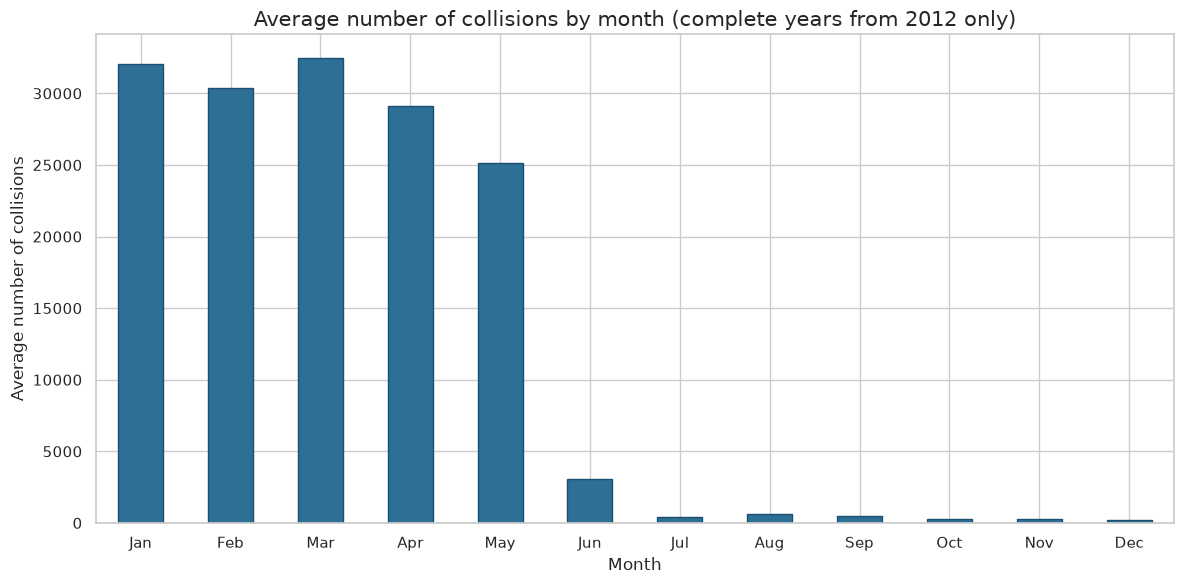

Peak: month **3**, mean **32498**.

Minimum: month **12**, mean **200**.

Only complete years are kept for the seasonal chart: **2012**.

In [7]:
df_monthly = year_month_counts[year_month_counts['year'].isin(model_years)].copy()

monthly_avg = year_month_matrix.loc[model_years].mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
monthly_avg.plot(kind='bar', ax=ax, color=MAIN_COLOR, edgecolor=DARK_COLOR)
ax.set_title("Average number of collisions by month (complete years from 2012 only)")
ax.set_xlabel("Month")
ax.set_ylabel("Average number of collisions")
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=0)
plt.tight_layout()
plt.show()

display(Markdown(f"Peak: month **{int(monthly_avg.idxmax())}**, mean **{monthly_avg.max():.0f}**."))
display(Markdown(f"Minimum: month **{int(monthly_avg.idxmin())}**, mean **{monthly_avg.min():.0f}**."))
display(Markdown(f"Only complete years are kept for the seasonal chart: **{', '.join(map(str, model_years))}**."))


The chart shows accident seasonality only for the complete years in the range starting from 2012. After the completeness check, 2012 is the only year left for this step in the current database.

<div class="alert alert-danger">
<b>😔 Needs fixing:</b> Here you need to check data completeness by year; if the data for some year is incomplete, that year should not be used, because it distorts the averages and produces incorrect conclusions
</div>

<div class="alert alert-info"> <b>🎓 Student comment:</b> Fixed: a month-by-month check has been added for every year starting from 2012; incomplete years are excluded from the subsequent analysis and from modelling.</div>

<div class="alert alert-danger">
<b>😔 Needs fixing V2:</b> I did not see the completeness check; you need to look at the amount of data per month for each year — starting from 2012 the data is incomplete and it distorts the analysis very badly
</div>

<div class="alert alert-info">
<b>🎓 Student comment:</b> Fixed: an analysis of data completeness by month has been added for every year starting from 2012. For each year a separate bar chart with the number of records per month has been plotted, together with an interim conclusion about completeness (complete/incomplete). Based on the results of the analysis, incomplete years (those with fewer than 12 months of data) have been excluded from modelling. Only complete years are included in the working set: 2012.
</div>

/tmp/ipykernel_3429858/4230589909.py:20: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/aiagent/.venvs/gradproj/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


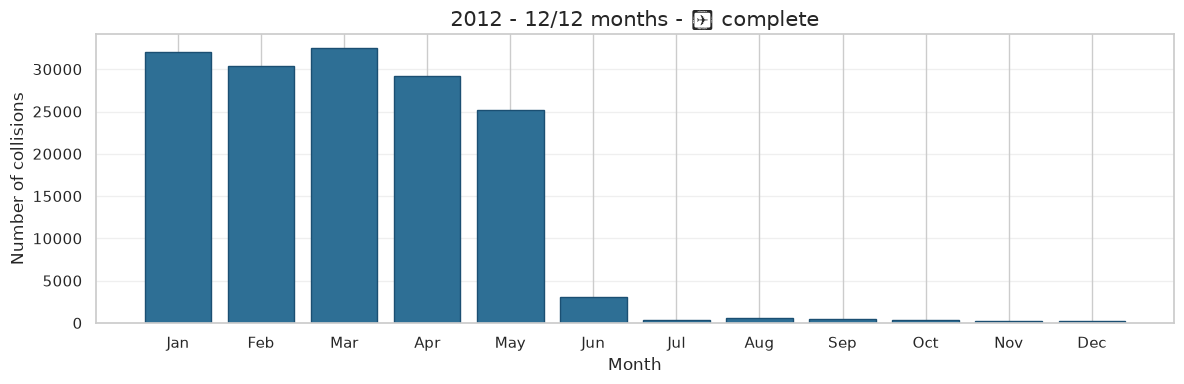

**Interim conclusion for 2012:** all 12 months are present. The year is complete, so it is kept for the analysis and the modelling.

/tmp/ipykernel_3429858/4230589909.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/aiagent/.venvs/gradproj/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


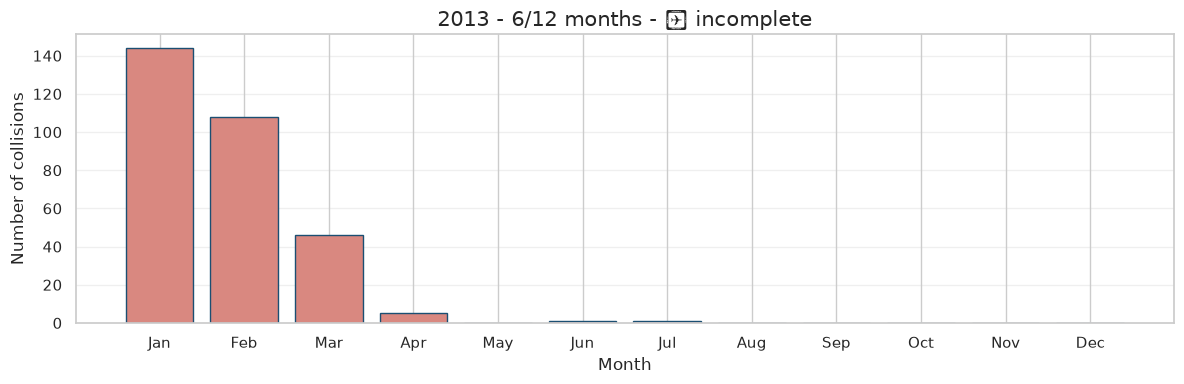

**Interim conclusion for 2013:** only 6 of 12 months are present. The year is incomplete, so it is excluded from the seasonal analysis and the modelling.

/tmp/ipykernel_3429858/4230589909.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/aiagent/.venvs/gradproj/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


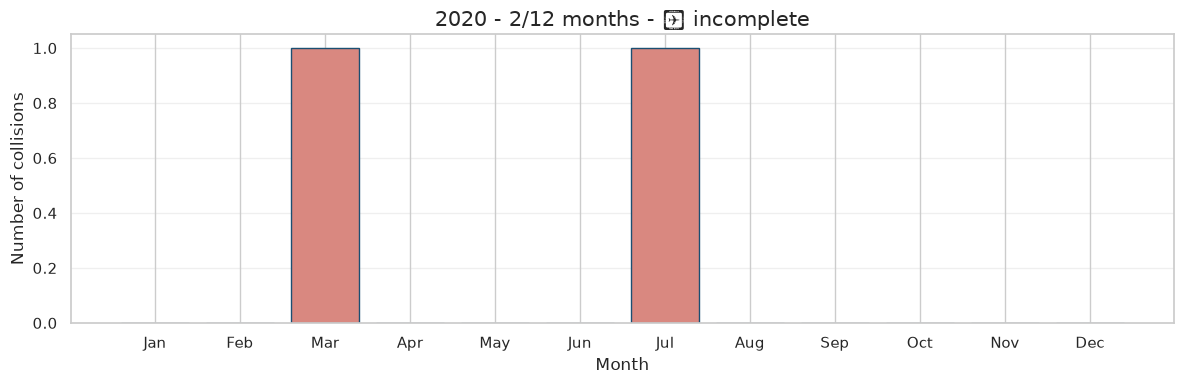

**Interim conclusion for 2020:** only 2 of 12 months are present. The year is incomplete, so it is excluded from the seasonal analysis and the modelling.

---
**Data completeness summary (from 2012):**
- Complete years (1): [2012]
- Incomplete years (2): [2013, 2020]
- Only complete years are used for the modelling.

In [8]:
# Assess data completeness for each year (from analysis_start_year)
colors_map = {True: MAIN_COLOR, False: '#D98880'}  # green = complete, red = incomplete

for year_to_plot in sorted(year_month_matrix.index):
    year_series = year_month_matrix.loc[year_to_plot]
    months_present = int(year_series.gt(0).sum())
    is_complete = (months_present == 12)
    
    fig, ax = plt.subplots(figsize=(12, 4))
    bar_color = colors_map[is_complete]
    ax.bar(range(1, 13), year_series.values, color=bar_color, edgecolor=DARK_COLOR)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of collisions')
    status = '✅ complete' if is_complete else '❌ incomplete'
    ax.set_title(f'{year_to_plot} - {months_present}/12 months - {status}')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Interim conclusion
    if is_complete:
        display(Markdown(
            f"**Interim conclusion for {year_to_plot}:** all 12 months are present. "
            f"The year is complete, so it is kept for the analysis and the modelling."
        ))
    else:
        display(Markdown(
            f"**Interim conclusion for {year_to_plot}:** only {months_present} of 12 months are present. "
            f"The year is incomplete, so it is excluded from the seasonal analysis and the modelling."
        ))

# Final summary
complete_years = sorted(df_completeness[df_completeness['months_count'] == 12]['year'].tolist())
incomplete_years = sorted(df_completeness[df_completeness['months_count'] < 12]['year'].tolist())
display(Markdown(
    f"---\n**Data completeness summary (from {analysis_start_year}):**\n"
    f"- Complete years ({len(complete_years)}): {complete_years}\n"
    f"- Incomplete years ({len(incomplete_years)}): {incomplete_years}\n"
    f"- Only complete years are used for the modelling."
))

**Data completeness summary.** Every year starting from 2012 has been analysed above. Complete years (all 12 months present) are kept for the seasonal analysis and for modelling. Incomplete ones are excluded. From this point on, all SQL queries and the working dataset are filtered by `model_years`.

**Data completeness summary.** Of the years from 2012 onwards, only **2012** turned out to be complete. The incomplete **2013** and **2020** are used neither in the seasonal analysis nor in the working set for the model. From here on, I restrict all the SQL queries below to the complete years from the `model_years` list.

#### 2.3.2. Analytical tasks for colleagues

1. Check how damage severity relates to the road condition `road_condition_1`.
2. Find the most frequent causes of road accidents by the `primary_collision_factor` field.
3. Compare the collision type `type_of_collision` with the number of parties `party_count`.
4. Look at how lighting `lighting` relates to the collision type `type_of_collision`.
5. Examine the relationship between the at-fault party's sobriety `party_sobriety` and the damage type `collision_damage`.
6. Study the vehicle age of at-fault parties using the `vehicle_age` field.

#### 2.3.3. At-fault party sobriety and damage type

First we build a summary by joining `parties` and `collisions`, then we plot the chart and state a short conclusion.

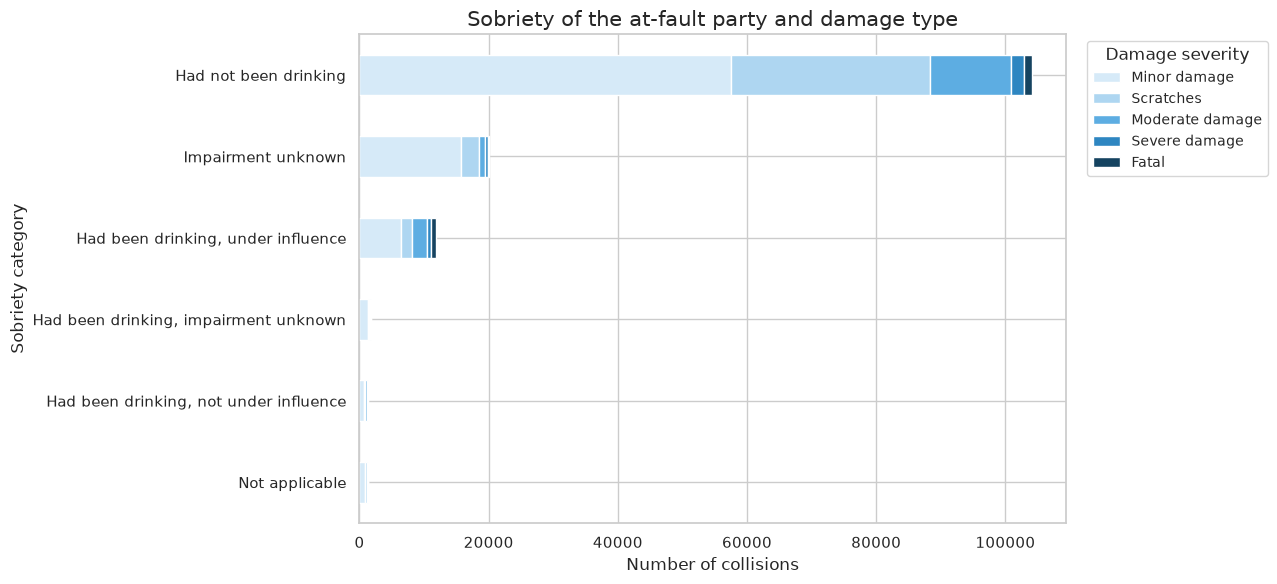

In [9]:
query_sobriety = text('''
    SELECT
        p.party_sobriety,
        c.collision_damage,
        COUNT(*) AS cnt
    FROM parties p
    JOIN collisions c ON p.case_id = c.case_id
    WHERE p.party_sobriety IS NOT NULL
      AND c.collision_damage IS NOT NULL
      AND p.at_fault = 1
      AND EXTRACT(YEAR FROM c.collision_date)::int IN :model_years
    GROUP BY p.party_sobriety, c.collision_damage
    ORDER BY cnt DESC, p.party_sobriety, c.collision_damage
''').bindparams(bindparam('model_years', expanding=True))

with engine.connect() as conn:
    df_sobriety = pd.read_sql(query_sobriety, conn, params={'model_years': model_years})

pivot = df_sobriety.pivot_table(index="party_sobriety", columns="collision_damage", values="cnt", fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]
pivot.index = [party_sobriety_labels.get(value, value) for value in pivot.index]
pivot.columns = [collision_damage_labels.get(value, value) for value in pivot.columns]

severity_order = [
    column
    for column in [
        "Minor damage",
        "Scratches",
        "Moderate damage",
        "Severe damage",
        "Fatal",
    ]
    if column in pivot.columns
]
pivot = pivot[severity_order]

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind="barh", stacked=True, ax=ax, color=DAMAGE_PALETTE[: len(pivot.columns)], edgecolor="white")
ax.set_title("Sobriety of the at-fault party and damage type")
ax.set_xlabel("Number of collisions")
ax.set_ylabel("Sobriety category")
ax.legend(title="Damage severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The chart shows how damage types are distributed across at-fault parties in different states. In absolute numbers the "had not been drinking" group leads, but that is due to its large size in the database. In relative terms, the categories showing signs of alcohol use have noticeably more moderate, severe and fatal outcomes, so sobriety looks like a meaningful feature for risk analysis. Dark shades now correspond to the most severe outcomes, so rare but severe categories are considerably easier to read.

#### 2.3.4. Vehicle age of at-fault parties

Here we need a summary of the at-fault party's vehicle age together with its frequency distribution.

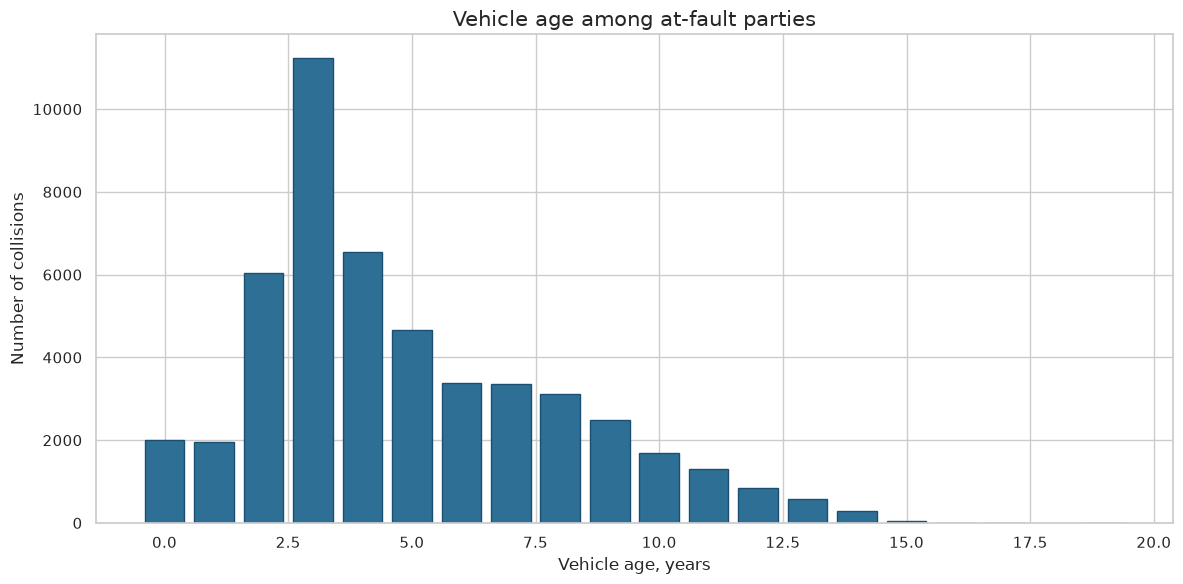

**Mean vehicle age:** 4.9 years

**Median vehicle age:** 4 years

In [10]:
query_vehicle_age = text('''
    SELECT
        v.vehicle_age,
        COUNT(*) AS cnt
    FROM parties p
    JOIN collisions c ON p.case_id = c.case_id
    JOIN vehicles v ON p.case_id = v.case_id AND p.party_number = v.party_number
    WHERE p.at_fault = 1
      AND v.vehicle_age IS NOT NULL
      AND v.vehicle_age BETWEEN 0 AND 50
      AND EXTRACT(YEAR FROM c.collision_date)::int IN :model_years
    GROUP BY v.vehicle_age
    ORDER BY v.vehicle_age
''').bindparams(bindparam('model_years', expanding=True))

with engine.connect() as conn:
    df_vehicle_age = pd.read_sql(query_vehicle_age, conn, params={'model_years': model_years})

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_vehicle_age["vehicle_age"], df_vehicle_age["cnt"], color=MAIN_COLOR, edgecolor=DARK_COLOR)
ax.set_title("Vehicle age among at-fault parties")
ax.set_xlabel("Vehicle age, years")
ax.set_ylabel("Number of collisions")
plt.tight_layout()
plt.show()

weighted_mean_age = (df_vehicle_age["vehicle_age"] * df_vehicle_age["cnt"]).sum() / df_vehicle_age["cnt"].sum()
cumulative_counts = df_vehicle_age["cnt"].cumsum()
weighted_median_age = int(df_vehicle_age.loc[cumulative_counts >= df_vehicle_age["cnt"].sum() / 2, "vehicle_age"].iloc[0])

display(Markdown(f"**Mean vehicle age:** {weighted_mean_age:.1f} years"))
display(Markdown(f"**Median vehicle age:** {weighted_median_age} years"))

The distribution shows that the vehicles most often involved in road accidents on the at-fault side are roughly three to five years old. The tallest bar falls on an age of 3 years, and the median of the distribution is 4 years. In shape this distribution resembles a Poisson distribution, which is typical of count processes and fits well with the idea of vehicle age as a natural ageing counter. For the project this means that vehicle age should be used not as a simple "the older, the more dangerous" feature, but as a non-linear factor tied to the structure of the fleet.

<div class="alert alert-success">
<b>👍 Success:</b> Excellent tasks and excellent solutions!
</div>

## Step 4. Preparing the dataset for the model

Now we assemble the final dataset according to the conditions of the task. Quality checks here are performed once, for the working dataset: we convert the column names to `snake_case`, remove exact duplicates, look for fuzzy matches, optimise the data types, and only after that move on to feature selection.

For modelling we use only the complete years in the range starting from 2012. According to the current check, this is the year 2012.

#### 4.1. Assembling and checking the working set

In [11]:
query_dataset = text('''
    SELECT
        p.case_id,
        p.at_fault,
        p.insurance_premium,
        c.weather_1,
        p.cellphone_in_use,
        c.location_type,
        c.road_surface,
        c.road_condition_1,
        c.lighting,
        c.control_device,
        c.collision_time,
        c.collision_date,
        v.vehicle_type,
        v.vehicle_transmission,
        v.vehicle_age
    FROM parties p
    JOIN collisions c ON p.case_id = c.case_id
    JOIN vehicles v ON p.case_id = v.case_id AND p.party_number = v.party_number
    WHERE p.party_type = 'car'
      AND c.collision_damage != 'scratch'
      AND EXTRACT(YEAR FROM c.collision_date)::int IN :model_years
    ORDER BY p.case_id, p.party_number
''').bindparams(bindparam('model_years', expanding=True))

with engine.connect() as conn:
    df = pd.read_sql(query_dataset, conn, params={'model_years': model_years})

df.columns = [
    re.sub(r"[^a-z0-9_]", "_", re.sub(r"(?<!^)(?=[A-Z])", "_", column).lower()).strip("_")
    for column in df.columns
]

display(Markdown(f"**Working set size: {df.shape[0]:,} rows and {df.shape[1]} columns**".replace(",", " ")))
display(pd.DataFrame({"column": df.columns}))
display(df.head())

**Working set size: 56 248 rows and 15 columns**

,column
0,case_id
1,at_fault
2,insurance_premium
3,weather_1
4,cellphone_in_use
5,location_type
6,road_surface
7,road_condition_1
8,lighting
9,control_device


,case_id,at_fault,insurance_premium,weather_1,cellphone_in_use,location_type,road_surface,road_condition_1,lighting,control_device,collision_time,collision_date,vehicle_type,vehicle_transmission,vehicle_age
0,5125160,0,42.0,cloudy,0.0,NaN,dry,other,daylight,none,07:40:00,2012-03-30,sedan,auto,2.0
1,5173738,0,31.0,clear,0.0,NaN,dry,normal,daylight,none,12:54:00,2012-04-02,sedan,auto,5.0
2,5269486,0,21.0,clear,0.0,NaN,dry,normal,daylight,functioning,16:35:00,2012-11-13,sedan,auto,1.0
3,5319820,0,31.0,clear,0.0,NaN,dry,normal,dark with street lights,functioning,19:32:00,2012-09-05,sedan,auto,4.0
4,5329109,0,41.0,clear,0.0,NaN,dry,normal,daylight,functioning,13:15:00,2012-11-03,coupe,auto,6.0


We check for exact duplicates and for categories with similar spellings, so that repeated rows and accidental discrepancies in text values do not reach the model's input.

In [12]:
df_duplicate_count = int(df.duplicated().sum())
display(Markdown(f"**Exact duplicates: {df_duplicate_count:,}**".replace(",", " ")))

if df_duplicate_count:
    df = df.drop_duplicates().reset_index(drop=True)
    display(Markdown(f"**{df.shape[0]:,}** rows remain after removal.".replace(",", " ")))
else:
    display(Markdown("Nothing to remove."))

df_checked_columns = []
df_fuzzy_results = []

for column in df.columns:
    dtype_name = str(df[column].dtype)
    is_text = (
        pd.api.types.is_object_dtype(df[column])
        or pd.api.types.is_string_dtype(df[column])
        or dtype_name == "category"
    )
    if not is_text:
        continue
    if column.endswith("_id") or "date" in column or "time" in column:
        continue

    unique_count = df[column].nunique(dropna=True)
    if 2 <= unique_count <= 300:
        df_checked_columns.append({"column": column, "unique values": unique_count})
        unique_values = df[column].dropna().astype(str).str.strip()
        unique_values = unique_values[unique_values != ""].unique()
        seen_values = set()

        for value in unique_values:
            if value in seen_values:
                continue
            matches = process.extract(value, unique_values, scorer=fuzz.ratio, limit=5)
            for match_value, score, _ in matches:
                if match_value != value and score >= 90 and match_value not in seen_values:
                    df_fuzzy_results.append(
                        {
                            "column": column,
                            "value 1": value,
                            "value 2": match_value,
                            "similarity": score,
                        }
                    )
                    seen_values.add(match_value)

display(pd.DataFrame(df_checked_columns))
if df_fuzzy_results:
    display(pd.DataFrame(df_fuzzy_results).sort_values(["column", "similarity"], ascending=[True, False]))
else:
    display(Markdown("Fuzzy matching found no suspiciously similar values."))

**Exact duplicates: 16**

**56 232** rows remain after removal.

,column,unique values
0,weather_1,7
1,location_type,3
2,road_surface,4
3,road_condition_1,8
4,lighting,5
5,control_device,4
6,vehicle_type,3
7,vehicle_transmission,2


,column,value 1,value 2,similarity
0,lighting,dark with street lights,dark with no street lights,93.877551


We optimise the data types to reduce memory usage before building the correlation matrix and moving on to modelling.

In [13]:
df_memory_before = df.memory_usage(deep=True)
df_dtypes_before = df.dtypes.astype(str)
df_info_before = io.StringIO()
df.info(buf=df_info_before, memory_usage="deep")

for column in df.select_dtypes(include=["int", "int16", "int32", "int64"]).columns:
    df[column] = pd.to_numeric(df[column], downcast="integer")
for column in df.select_dtypes(include=["float", "float16", "float32", "float64"]).columns:
    df[column] = pd.to_numeric(df[column], downcast="float")
for column in df.columns:
    if pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(df[column]):
        unique_count = df[column].nunique(dropna=True)
        if len(df) and unique_count and unique_count / len(df) <= 0.3 and unique_count <= 1000:
            df[column] = df[column].astype("category")

df_memory_after = df.memory_usage(deep=True)
df_dtypes_after = df.dtypes.astype(str)
df_info_after = io.StringIO()
df.info(buf=df_info_after, memory_usage="deep")

df_optimization = (
    pd.DataFrame(
        {
            "type before": df_dtypes_before,
            "type after": df_dtypes_after,
            "memory before, MB": (df_memory_before / 1024**2).round(3),
            "memory after, MB": (df_memory_after / 1024**2).round(3),
            "saving, MB": ((df_memory_before - df_memory_after) / 1024**2).round(3),
        }
    )
    .sort_values("saving, MB", ascending=False)
)
df_top_savings = df_optimization[df_optimization["saving, MB"] > 0].head(12)

df_before_total = df_memory_before.sum() / 1024**2
df_after_total = df_memory_after.sum() / 1024**2

display(Markdown(f"**Memory before optimisation: {df_before_total:.2f} MB**"))
display(Markdown(f"```text\n{df_info_before.getvalue()}\n```"))
display(Markdown(f"**Memory after optimisation: {df_after_total:.2f} MB**"))
display(Markdown(f"```text\n{df_info_after.getvalue()}\n```"))
display(Markdown(f"**Memory saved: {df_before_total - df_after_total:.2f} MB**"))
display(df_top_savings)

display(df.describe(include="all").T.fillna(""))

class_balance = df["at_fault"].value_counts().rename_axis("class").to_frame("number")
class_share = df["at_fault"].value_counts(normalize=True).round(4).rename_axis("class").to_frame("share")
display(Markdown("**Class balance**"))
display(class_balance)
display(class_share)

**Memory before optimisation: 13.23 MB**

```text
<class 'pandas.DataFrame'>
RangeIndex: 56232 entries, 0 to 56231
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   case_id               56232 non-null  str    
 1   at_fault              56232 non-null  int64  
 2   insurance_premium     55685 non-null  float64
 3   weather_1             56064 non-null  str    
 4   cellphone_in_use      51764 non-null  float64
 5   location_type         25922 non-null  str    
 6   road_surface          55884 non-null  str    
 7   road_condition_1      55983 non-null  str    
 8   lighting              56078 non-null  str    
 9   control_device        56017 non-null  str    
 10  collision_time        56144 non-null  object 
 11  collision_date        56232 non-null  object 
 12  vehicle_type          56232 non-null  str    
 13  vehicle_transmission  55373 non-null  str    
 14  vehicle_age           54539 non-null  float64
dtypes: float64(3), int64(1), object(2), str(9)
memory usage: 13.2 MB

```

**Memory after optimisation: 4.63 MB**

```text
<class 'pandas.DataFrame'>
RangeIndex: 56232 entries, 0 to 56231
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   case_id               56232 non-null  str     
 1   at_fault              56232 non-null  int8    
 2   insurance_premium     55685 non-null  float32 
 3   weather_1             56064 non-null  category
 4   cellphone_in_use      51764 non-null  float32 
 5   location_type         25922 non-null  category
 6   road_surface          55884 non-null  category
 7   road_condition_1      55983 non-null  category
 8   lighting              56078 non-null  category
 9   control_device        56017 non-null  category
 10  collision_time        56144 non-null  object  
 11  collision_date        56232 non-null  category
 12  vehicle_type          56232 non-null  category
 13  vehicle_transmission  55373 non-null  category
 14  vehicle_age           54539 non-null  float32 
dtypes: category(9), float32(3), int8(1), object(1), str(1)
memory usage: 4.6 MB

```

**Memory saved: 8.59 MB**

,type before,type after,"memory before, MB","memory after, MB","saving, MB"
collision_date,object,category,2.145,0.121,2.024
lighting,str,category,1.120,0.054,1.066
control_device,str,category,0.773,0.054,0.719
road_condition_1,str,category,0.764,0.054,0.710
weather_1,str,category,0.715,0.054,0.661
vehicle_type,str,category,0.704,0.054,0.650
vehicle_transmission,str,category,0.703,0.054,0.649
location_type,str,category,0.606,0.054,0.552
road_surface,str,category,0.596,0.054,0.543
at_fault,int64,int8,0.429,0.054,0.375


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,56232,44832,5542351,8,,,,,,,
at_fault,56232.0,,,,0.50457,0.499984,0.0,0.0,1.0,1.0,1.0
insurance_premium,55685.0,,,,37.607685,16.328442,0.0,24.0,34.0,49.0,105.0
weather_1,56064,7,clear,45079,,,,,,,
cellphone_in_use,51764.0,,,,0.020362,0.141235,0.0,0.0,0.0,0.0,1.0
location_type,25922,3,highway,21314,,,,,,,
road_surface,55884,4,dry,50227,,,,,,,
road_condition_1,55983,8,normal,54051,,,,,,,
lighting,56078,5,daylight,38049,,,,,,,
control_device,56017,4,none,37567,,,,,,,


**Class balance**

,number
class,
1,28373
0,27859


,share
class,
1,0.5046
0,0.4954


The working set is suitable for modelling: exact duplicates have been removed. The set contains only features that are available before the trip.

<div class="alert alert-success">
<b>👍 Success:</b> The data has been extracted and the query is correct!
</div>

<div class="alert alert-danger">
<s><b>😔 Needs fixing:</b> Most of these features describe the accident itself and are unknown before the trip, so they should not be extracted. If you list specific features in the query, you need to remove the ones that are unknown before the trip</s>
</div>

<div class="alert alert-info"> <b>🎓 Student comment:</b> Fixed: the features that describe the accident itself and are unknown before the trip have been removed. Only the ones available in advance are kept (weather, time, road type).</div>

#### 4.2. Exploratory analysis and reasoning about the features

Below it is important not only to list the features, but also to separate useful factors from data leakage. For a forecast made before the trip starts, we cannot rely on features that only appear after the collision.

| Feature | Why it may matter | What the analysis shows | Available before the trip | Decision |
|---|---|---|---|---|
| `party_sobriety` | Alcohol impairs reaction time and control of the car. | Under intoxication the share of at-fault parties is around 95%. | No, it is recorded only after the accident. | Exclude. |
| `party_drug_physical` | Fatigue and being under the influence of drugs also degrade driving quality. | For the `sleepy/fatigued` and `under drug influence` categories the share of at-fault parties is above 90%. | No, it is recorded only after the accident. | Exclude. |
| `cellphone_in_use` | A phone distracts the driver. | There is a difference, but a moderate one: about 53.6% versus 49.9%. | Yes, the company knows how its cars are equipped. | Keep. |
| `insurance_premium` | The premium reflects the accumulated risk profile of the driver and the vehicle. | In the bottom quartile of the premium the share of at-fault parties is above 63%, in the middle range it is lower. | Yes, if the tariff is stored in the system. | Keep. |
| `weather_1` | Bad weather reduces visibility and grip. | Snow, rain and fog are noticeably worse than clear weather. | Yes, via the forecast and weather data. | Keep. |
| `location_type` | Ramps, highways and intersections imply different levels of manoeuvring difficulty. | On ramps the share of at-fault parties is higher than at intersections. | Yes, it can be computed when the route is planned. | Keep. |
| `collision_damage` | Damage severity is related to the force and the scenario of the crash. | For severe and fatal cases the share of at-fault parties is higher than for minor damage. | No, this is an outcome of the crash. | Exclude. |
| `primary_collision_factor` | It describes the cause of the accident almost directly. | The relationship is strong, but the feature only appears once the incident has been investigated. | No. | Exclude. |
| `pcf_violation_category` | It details the violation and almost duplicates the analysis of the cause. | One of the strongest features, but it is a label assigned after the crash. | No. | Exclude. |
| `type_of_collision` | Different collision types are related to fault in different ways. | `overturned` and `hit object` lead to class 1 noticeably more often. | No, this describes an event that has already happened. | Exclude. |
| `road_surface` | A wet or snow-covered surface increases the risk of an error. | Snow and a wet road are worse than a dry surface. | Yes, from weather and road data. | Keep. |
| `road_condition_1` | Flooding, narrowing and a loose surface make the car harder to control. | The highest shares of at-fault parties are for `flooded`, `loose material` and `reduced width`. | Yes, if road-service data is available. | Keep. |
| `lighting` | Visibility directly affects the probability of an error. | In darkness with no street lighting the share of at-fault parties is higher than in daylight. | Yes, from the time of day and the road type. | Keep. |
| `control_device` | The presence or absence of traffic control changes how difficult the passage is. | Where there is no traffic control, the share of at-fault parties is higher than where the devices are functioning. | Yes, from the road map. | Keep. |
| `party_count` | The number of parties reflects the scenario of the incident. | In single-party accidents the share of at-fault parties is around 91%. | No, this is known only after the crash. | Exclude. |
| `vehicle_type` | Body type and vehicle mass are related to driving style and stability. | For `coupe` the share of at-fault parties is higher than for `sedan`. | Yes, from the vehicle record. | Keep. |
| `vehicle_transmission` | The transmission may be related to driving style. | Cars with `manual` have a higher share of at-fault parties than those with `auto`. | Yes, from the vehicle record. | Keep. |
| `vehicle_age` | Age is related to wear and to the condition of the car. | The densest range is 3–5 years, which means the relationship is not linear. | Yes, from the vehicle record. | Keep. |

<div class="alert alert-danger">
<s><b>😔 Needs fixing:</b> party_sobriety, party_drug_physical - are not known before the trip, they are recorded only after the accident, cellphone_in_use - is known, the company knows how its cars are equipped location_type, the distance to the main road and the presence of an intersection - can be computed by planning the route before the trip.</s>
</div>

<div class="alert alert-info"> <b>🎓 Student comment:</b> Noted, fixed.</div>

In the preliminary selection we keep the features that can be known before the trip starts: `insurance_premium`, `weather_1`, `road_surface`, `road_condition_1`, `lighting`, `control_device`, `vehicle_type`, `vehicle_transmission`, `vehicle_age`, `cellphone_in_use`, `location_type`. The post-event fields have been excluded from the SQL query.

Before plotting the charts we add time-based features — these are also known before the trip starts.

<div class="alert alert-success">
<b>👍 Success:</b> Everything is correct!
</div>

In [14]:
df["hour_of_day"] = pd.to_datetime(
    df["collision_time"].astype(str),
    format="%H:%M:%S",
    errors="coerce",
).dt.hour

def get_time_bucket(hour):
    if pd.isna(hour):
        return "unknown"
    if 22 <= hour or hour < 6:
        return "night"
    if 6 <= hour < 10:
        return "morning"
    if 10 <= hour < 16:
        return "day"
    return "evening"

df["time_bucket"] = df["hour_of_day"].apply(get_time_bucket)
df["month"] = pd.to_datetime(df["collision_date"]).dt.month
df["is_weekend"] = pd.to_datetime(df["collision_date"]).dt.dayofweek.isin([5, 6]).astype(int)

temporal_preview = df[
    ["collision_time", "hour_of_day", "time_bucket", "collision_date", "month", "is_weekend"]
].head()
display(temporal_preview)

,collision_time,hour_of_day,time_bucket,collision_date,month,is_weekend
0,07:40:00,7.0,morning,2012-03-30,3,0
1,12:54:00,12.0,day,2012-04-02,4,0
2,16:35:00,16.0,evening,2012-11-13,11,0
3,19:32:00,19.0,evening,2012-09-05,9,0
4,13:15:00,13.0,day,2012-11-03,11,1


#### 4.2.1. Frequency analysis of the distributions by target variable

Now we look at each feature separately and compare how the target classes are distributed within its values. For categorical fields we use stacked horizontal share charts, and for numeric ones — overlaid distributions with the median for each class.

In [15]:
feature_labels = {
    'insurance_premium': 'Insurance premium',
    'weather_1': 'Weather conditions',
    'road_surface': 'Road surface',
    'road_condition_1': 'Road condition',
    'lighting': 'Lighting',
    'control_device': 'Control device',
    'vehicle_type': 'Vehicle type',
    'vehicle_transmission': 'Transmission',
    'vehicle_age': 'Vehicle age (years)',
    'cellphone_in_use': 'Cellphone use',
    'location_type': 'Location type',
    'hour_of_day': 'Hour of the day',
    'time_bucket': 'Part of the day',
    'month': 'Month',
    'is_weekend': 'Weekend',
}
feature_labels['at_fault'] = 'Fault'

feature_value_labels = {
    'weather_1': {
        'clear': 'Clear', 'cloudy': 'Cloudy', 'raining': 'Rain',
        'fog': 'Fog', 'snowing': 'Snow', 'wind': 'Wind',
        'other': 'Other', 'unknown': 'Unknown',
    },
    'road_surface': {
        'dry': 'Dry', 'slippery': 'Slippery', 'snowy': 'Snowy',
        'wet': 'Wet', 'unknown': 'Unknown',
    },
    'road_condition_1': {
        'construction': 'Roadworks', 'flooded': 'Flooded', 'holes': 'Potholes',
        'loose material': 'Loose material', 'normal': 'Normal',
        'obstruction': 'Object', 'other': 'Other',
        'reduced width': 'Reduced width', 'unknown': 'Unknown',
    },
    'lighting': {
        'dark with no street lights': 'Dark, no street lights',
        'dark with street lights': 'Dark, with street lights',
        'dark with street lights not functioning': 'Dark, street lights not working',
        'daylight': 'Daylight', 'dusk or dawn': 'Dusk or dawn',
        'unknown': 'Unknown',
    },
    'control_device': {
        'functioning': 'Control device working', 'none': 'No control device',
        'not functioning': 'Control device not working',
        'obscured': 'View obstructed', 'unknown': 'Unknown',
    },
    'vehicle_type': {
        'coupe': 'Coupe', 'other': 'Other', 'sedan': 'Sedan',
    },
    'vehicle_transmission': {
        'auto': 'Automatic', 'manual': 'Manual',
        'unknown': 'Unknown',
    },
    'time_bucket': {
        'night': 'Night', 'morning': 'Morning', 'day': 'Day',
        'evening': 'Evening', 'unknown': 'Unknown', 'missing': 'Missing',
    },
    'is_weekend': {
        '0': 'Weekday', '1': 'Weekend',
    },
}

def plot_categorical_by_target(df, column, target='at_fault', labels_ru=None):
    plot_df = df[[column, target]].copy()
    plot_df[column] = plot_df[column].astype('string').fillna('unknown')
    counts = plot_df.groupby([column, target], dropna=False).size().unstack(fill_value=0)
    counts = counts.reindex(columns=[0, 1], fill_value=0)
    totals = counts.sum(axis=1).sort_values(ascending=False)
    counts = counts.loc[totals.index]
    shares = counts.div(totals, axis=0).mul(100)
    title = labels_ru.get(column, column) if labels_ru else column
    value_labels = feature_value_labels.get(column, {})
    categories = [value_labels.get(value, value) for value in counts.index]
    fig_height = max(4.5, 0.55 * len(categories) + 2.5)
    fig, ax = plt.subplots(figsize=(14, fig_height))
    ax.barh(categories, shares[0], color='#4C78A8', label='Not at fault')
    ax.barh(categories, shares[1], left=shares[0], color='#E45756', label='At fault')
    for idx, (share_0, share_1) in enumerate(zip(shares[0], shares[1])):
        if share_0 >= 4:
            ax.text(share_0 / 2, idx, f'{share_0:.1f}%', va='center', ha='center', color='white', fontsize=10, fontweight='bold')
        if share_1 >= 4:
            ax.text(share_0 + share_1 / 2, idx, f'{share_1:.1f}%', va='center', ha='center', color='white', fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel('Share of observations within the category, %')
    ax.set_ylabel('Feature values')
    ax.set_title(f'{title}: fault rate by category')
    ax.legend(title='Target class', loc='lower right')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_numerical_by_target(df, column, target='at_fault', labels_ru=None, bins=20, xticks=None, xticklabels=None):
    plot_df = df[[column, target]].dropna().copy()
    series_0 = plot_df.loc[plot_df[target] == 0, column]
    series_1 = plot_df.loc[plot_df[target] == 1, column]
    title = labels_ru.get(column, column) if labels_ru else column
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.hist(series_0, bins=bins, density=True, alpha=0.55, color='#4C78A8', label='Not at fault')
    ax.hist(series_1, bins=bins, density=True, alpha=0.55, color='#E45756', label='At fault')
    median_0 = float(series_0.median())
    median_1 = float(series_1.median())
    ax.axvline(median_0, color='#4C78A8', linestyle='--', linewidth=2, label=f'Median, not at fault: {median_0:.1f}')
    ax.axvline(median_1, color='#E45756', linestyle='--', linewidth=2, label=f'Median, at fault: {median_1:.1f}')
    if xticks is not None:
        ax.set_xticks(xticks)
        if xticklabels is not None:
            ax.set_xticklabels(xticklabels)
    ax.set_title(f'{title}: distribution by target class')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

#### 4.2.5. Insurance premium

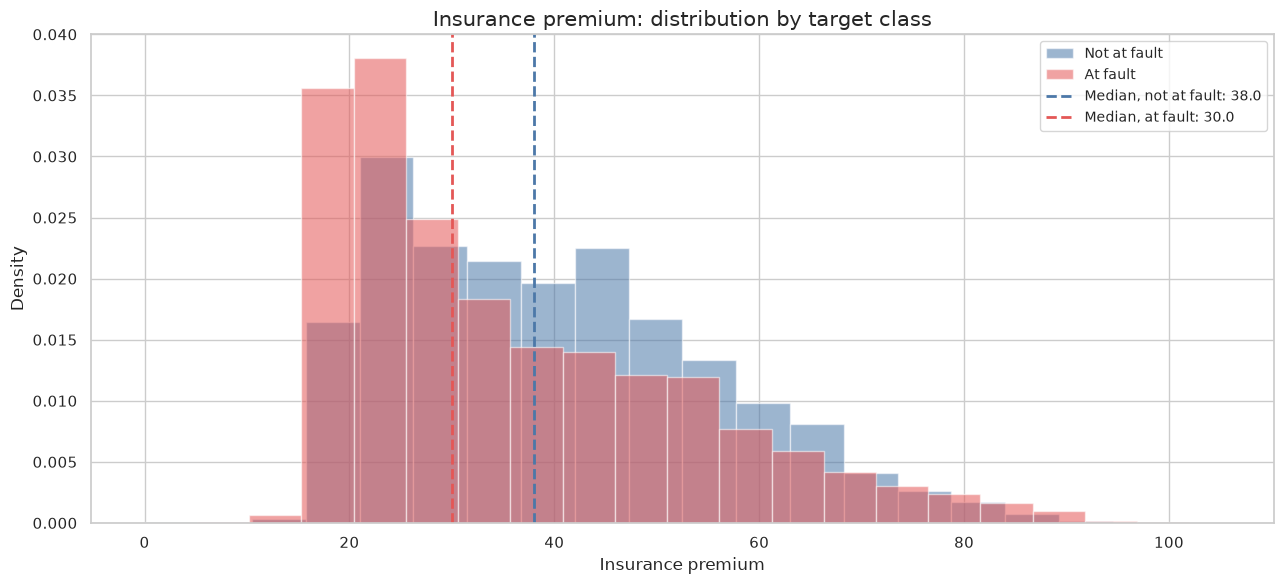

In [16]:
plot_numerical_by_target(df, 'insurance_premium', labels_ru=feature_labels)

`insurance_premium` does separate the classes and at the same time is admissible for the model: the tariff is already stored in the car-sharing system before the trip starts. This is not a behavioural feature of a specific session, but an aggregated risk signal that can complement the driver's state, the road context and the characteristics of the vehicle. So it makes sense to keep the field in the final set and check its contribution at the model level.

#### 4.2.6. Weather conditions

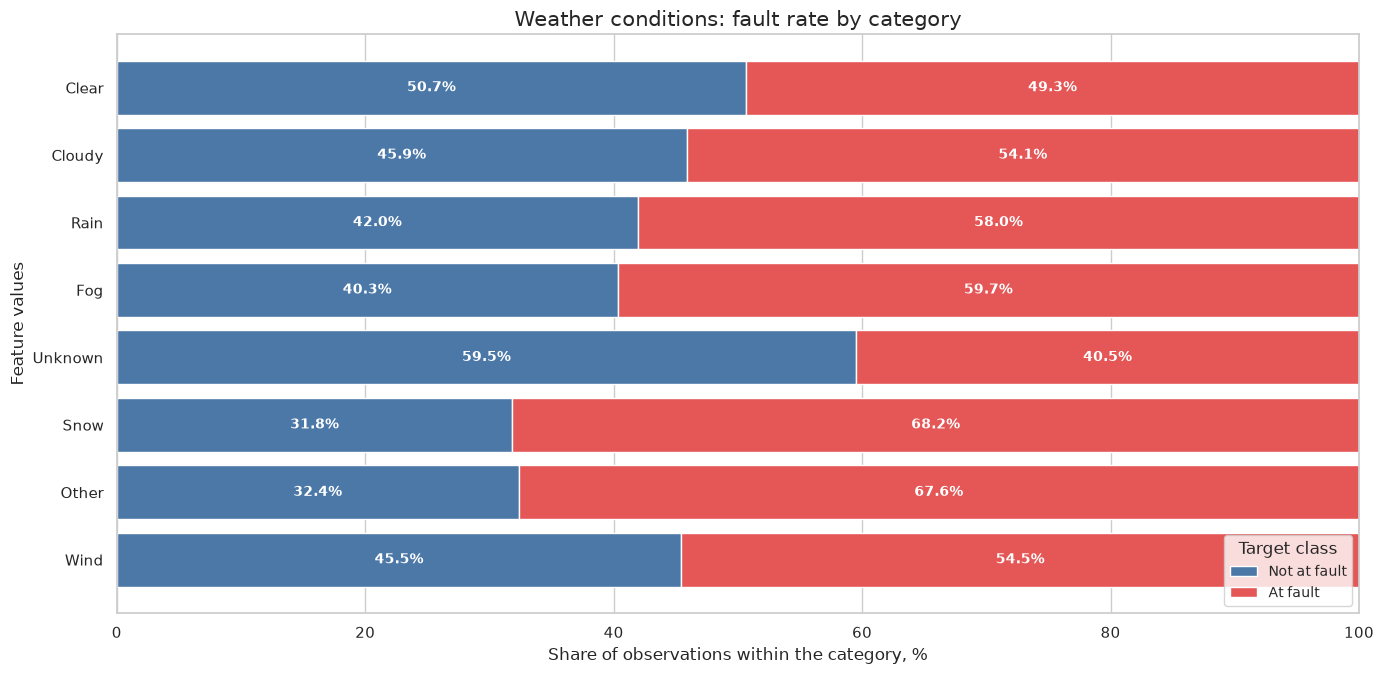

In [17]:
plot_categorical_by_target(df, 'weather_1', labels_ru=feature_labels)

Clear weather dominates in terms of the number of observations, and within it the classes are close to balanced. In snow, rain and fog the share of at-fault parties is higher, but these categories are themselves relatively rare. The feature captures the road context, yet its contribution is limited by the low frequency of adverse conditions.

#### 4.2.12. Road surface

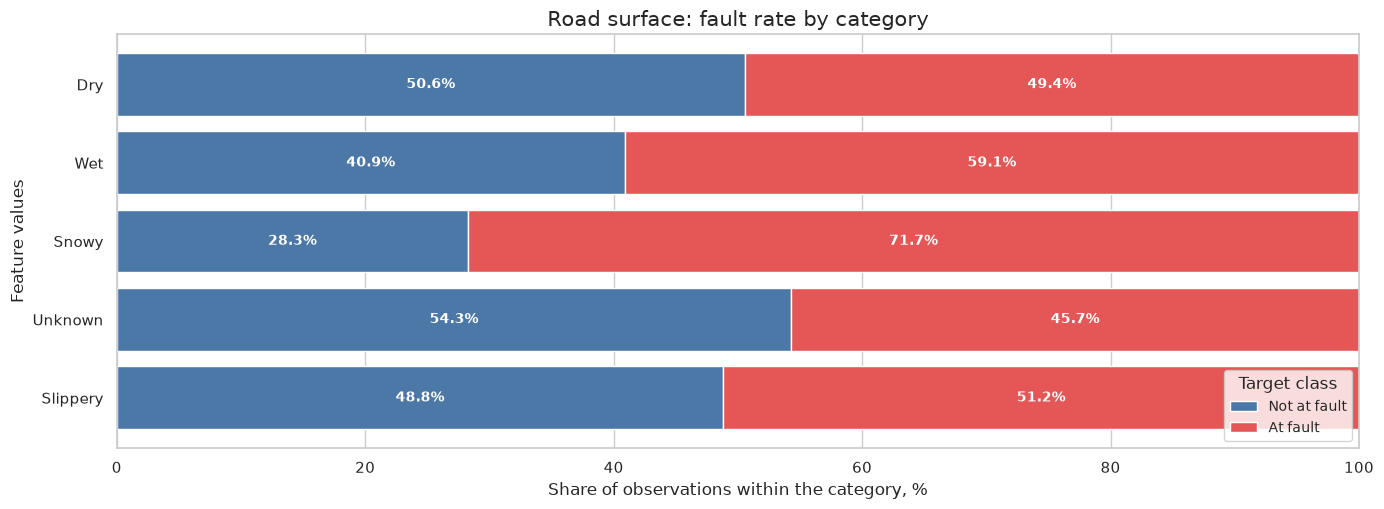

In [18]:
plot_categorical_by_target(df, 'road_surface', labels_ru=feature_labels)

A dry surface prevails and produces an almost neutral distribution. On a wet and especially on a snow-covered road the share of at-fault parties is higher, but such cases are few. This is a useful contextual feature, but not a strong separator on its own.

#### 4.2.13. Road condition

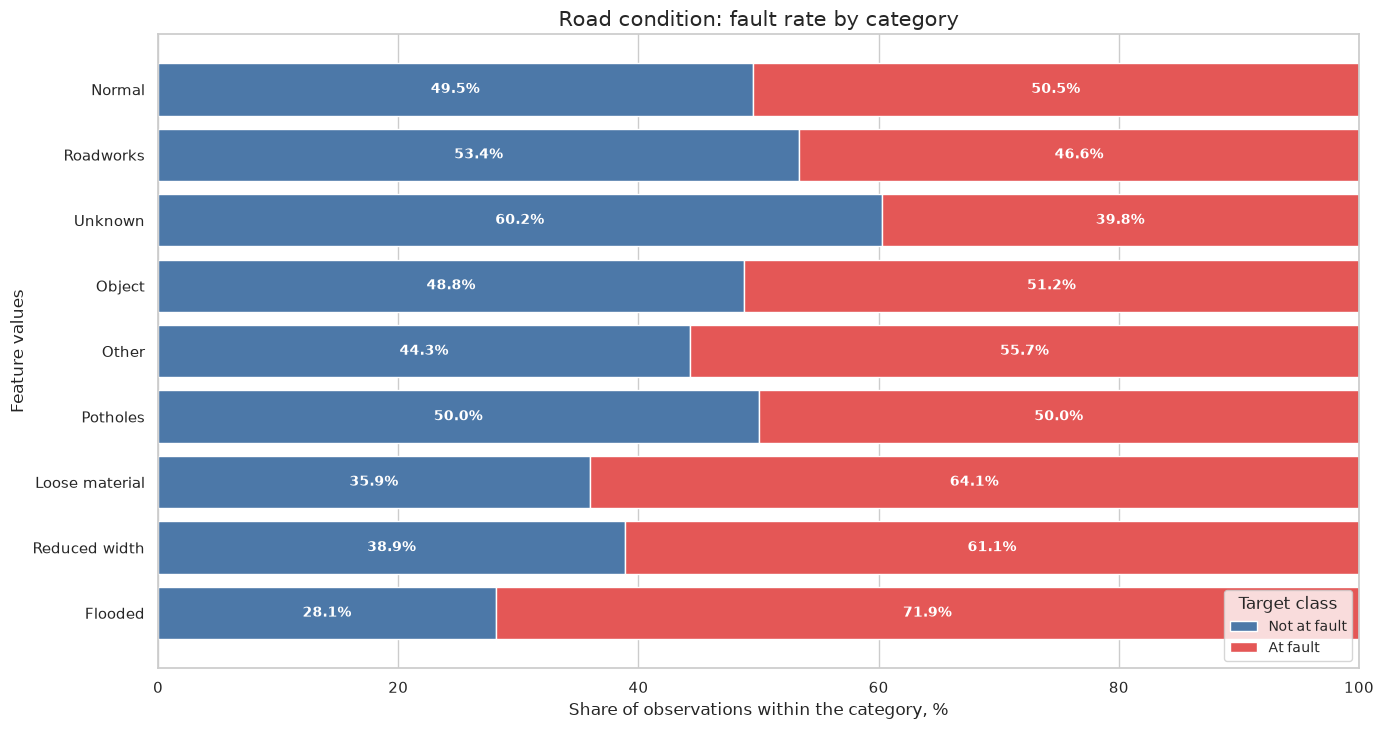

In [19]:
plot_categorical_by_target(df, 'road_condition_1', labels_ru=feature_labels)

A normal road condition almost entirely determines the shape of the distribution, and most of the remaining categories are too rare. With flooding, a loose surface and narrowing, the share of at-fault parties is higher, but there are few such observations. There is a conclusion to draw from this feature, but it is less robust than the one based on the driver's state.

#### 4.2.14. Lighting

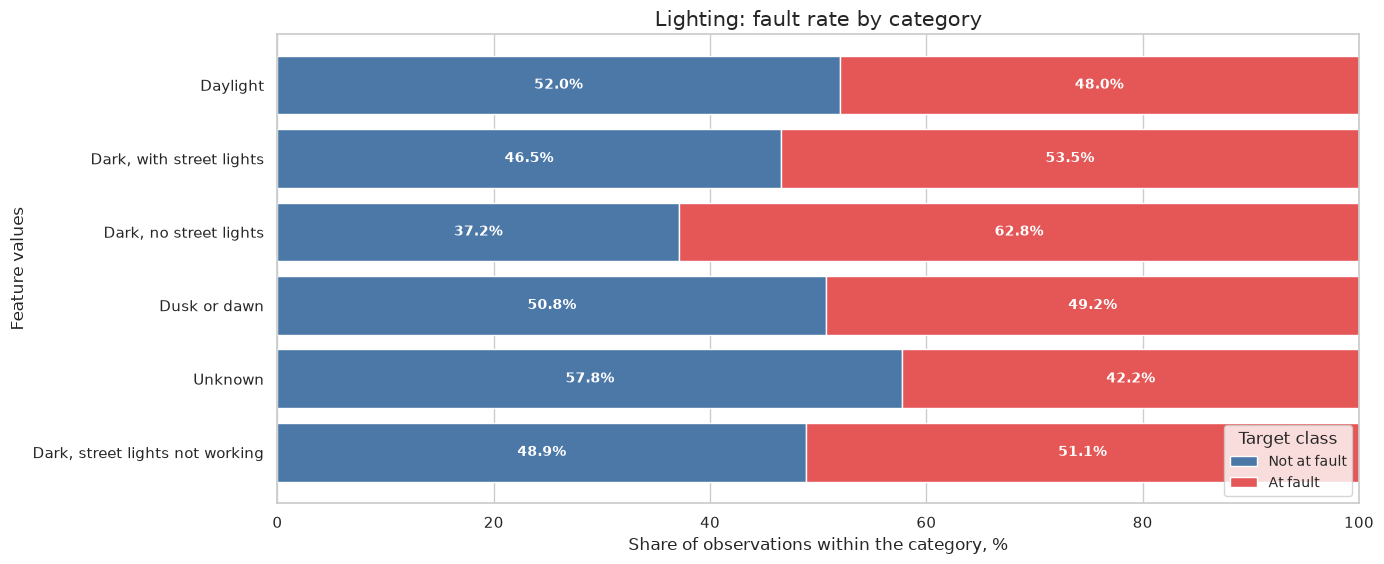

In [20]:
plot_categorical_by_target(df, 'lighting', labels_ru=feature_labels)

Lighting produces a clear gradient: in daylight the share of at-fault parties is lower, in darkness with functioning street lights it is higher, and with no street light — higher still. The feature looks informative and is logically tied to visibility. In terms of signal strength it still falls short of the driver's state and of the characteristics recorded after the crash.

#### 4.2.15. Traffic control device

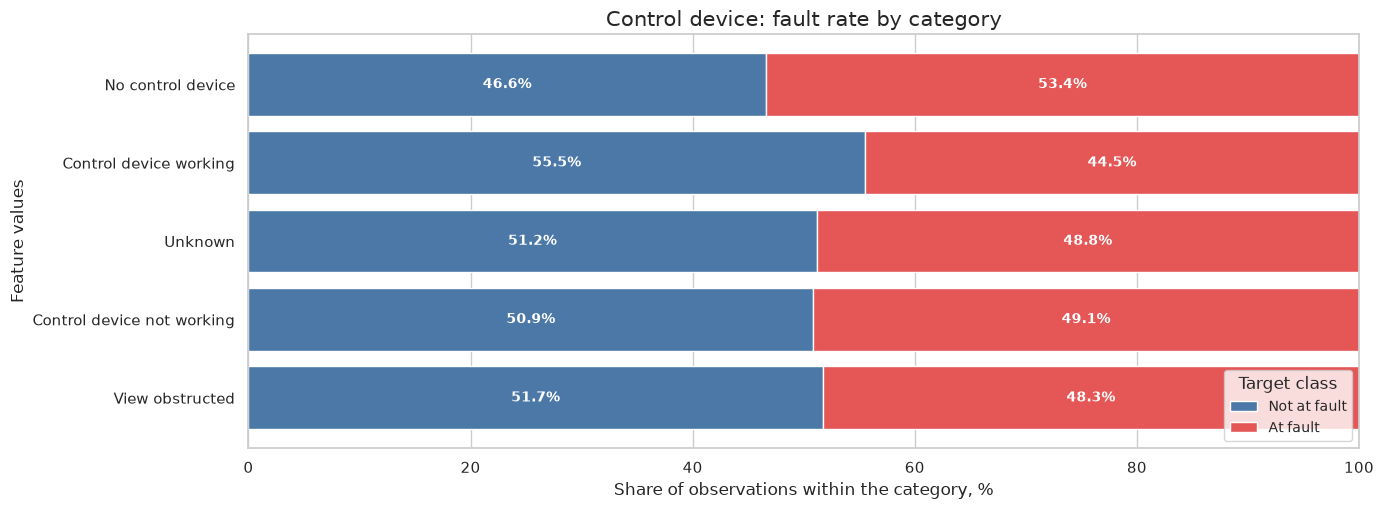

In [21]:
plot_categorical_by_target(df, 'control_device', labels_ru=feature_labels)

Where there is no traffic control, class 1 occurs noticeably more often than where the devices are functioning. The remaining categories are very small in volume, so the main information here is concentrated in the contrast between the presence and the absence of traffic control. The feature is useful, but its signal is moderate.

#### 4.2.17. Vehicle type

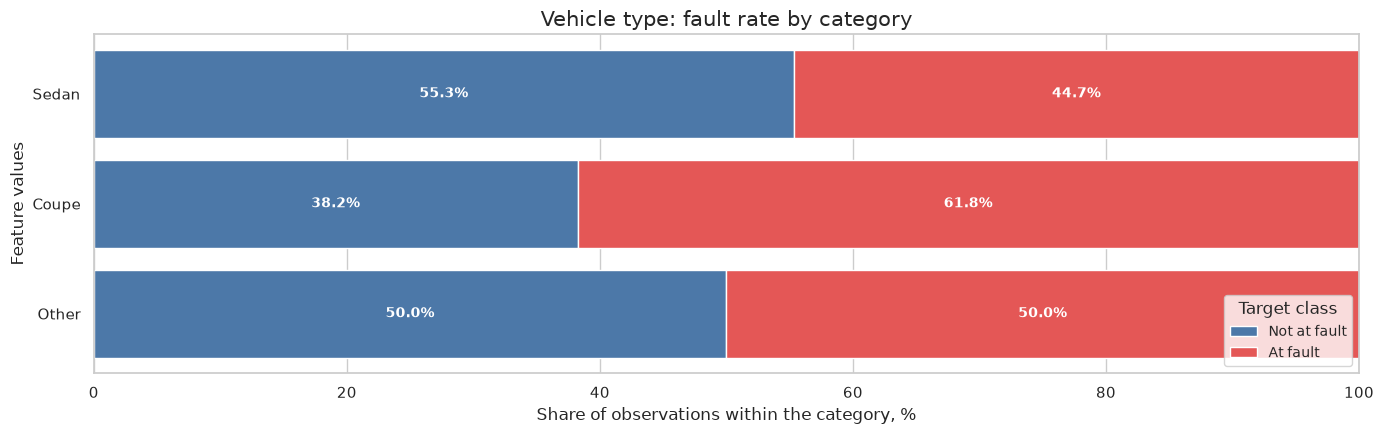

In [22]:
plot_categorical_by_target(df, 'vehicle_type', labels_ru=feature_labels)

Coupes are associated with class 1 noticeably more often than sedans. The difference is visible on large groups and therefore looks robust. But the feature essentially reduces to a comparison of the two most common body types and is weaker than more direct indicators of the driver's state.

#### 4.2.18. Transmission

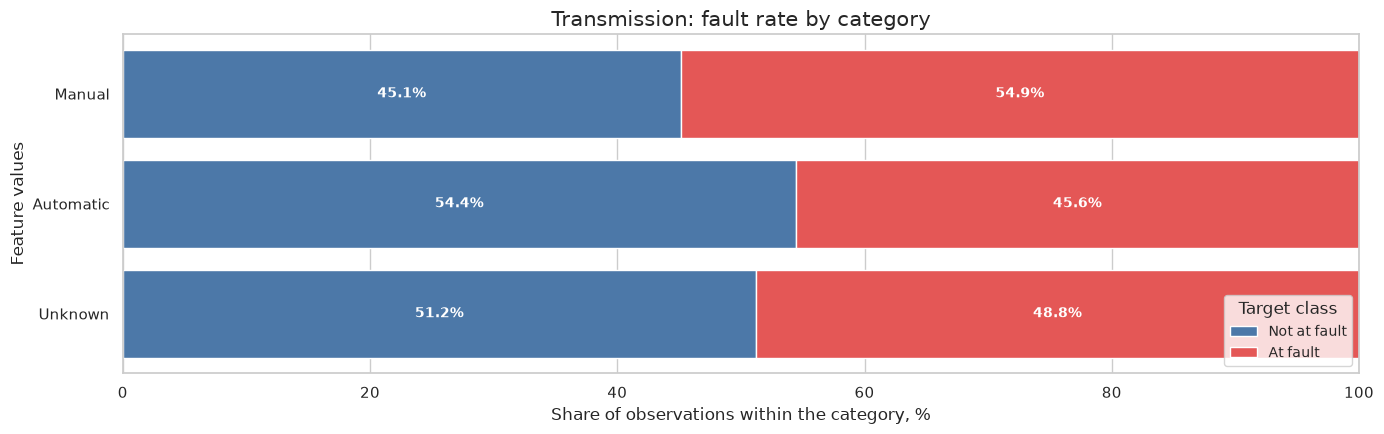

In [23]:
plot_categorical_by_target(df, 'vehicle_transmission', labels_ru=feature_labels)

For a manual transmission the share of class 1 is higher than for an automatic one. The difference is noticeable on large groups and does not look accidental. That said, it most likely reflects accompanying characteristics of the driver and the vehicle rather than an independent causal effect.

#### 4.2.19. Vehicle age

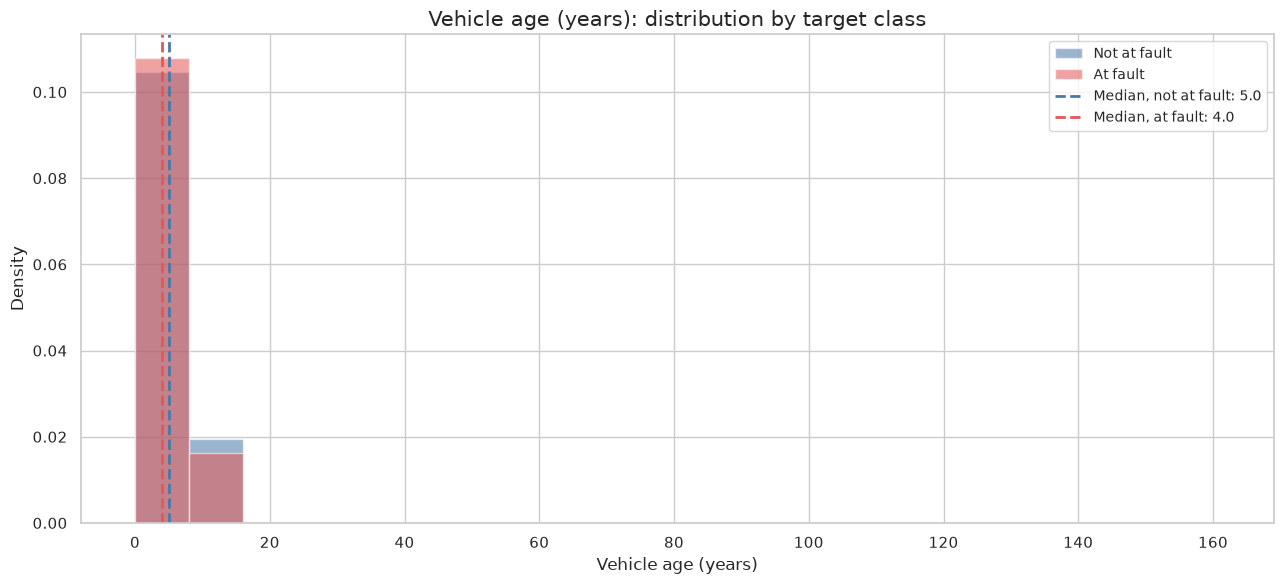

In [24]:
plot_numerical_by_target(df, 'vehicle_age', labels_ru=feature_labels)

The distributions overlap heavily, although class 1 has a slightly lower median and its mass of observations is shifted a little more towards newer cars. The relationship is noticeable but remains weak and non-linear. On its own this feature separates the classes poorly and needs to be combined with other factors.

#### 4.2.20. Hour of the day

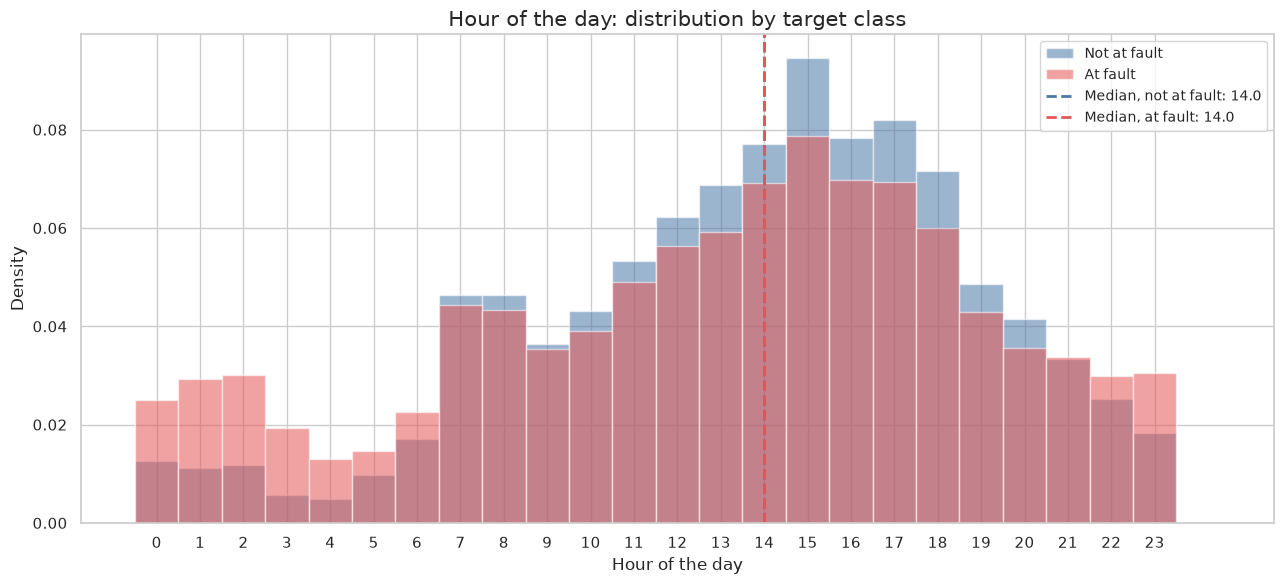

In [25]:
plot_numerical_by_target(
    df,
    'hour_of_day',
    labels_ru=feature_labels,
    bins=np.arange(-0.5, 24.6, 1),
    xticks=np.arange(0, 24, 1),
)

The most pronounced shift is visible at night and in the early morning: in these hours the share of class 1 is noticeably higher than during the day and in the evening. This means that the time of the trip itself really does add a useful signal and can work as an admissible proxy for fatigue, poor visibility and reduced attention.

#### 4.2.21. Part of the day

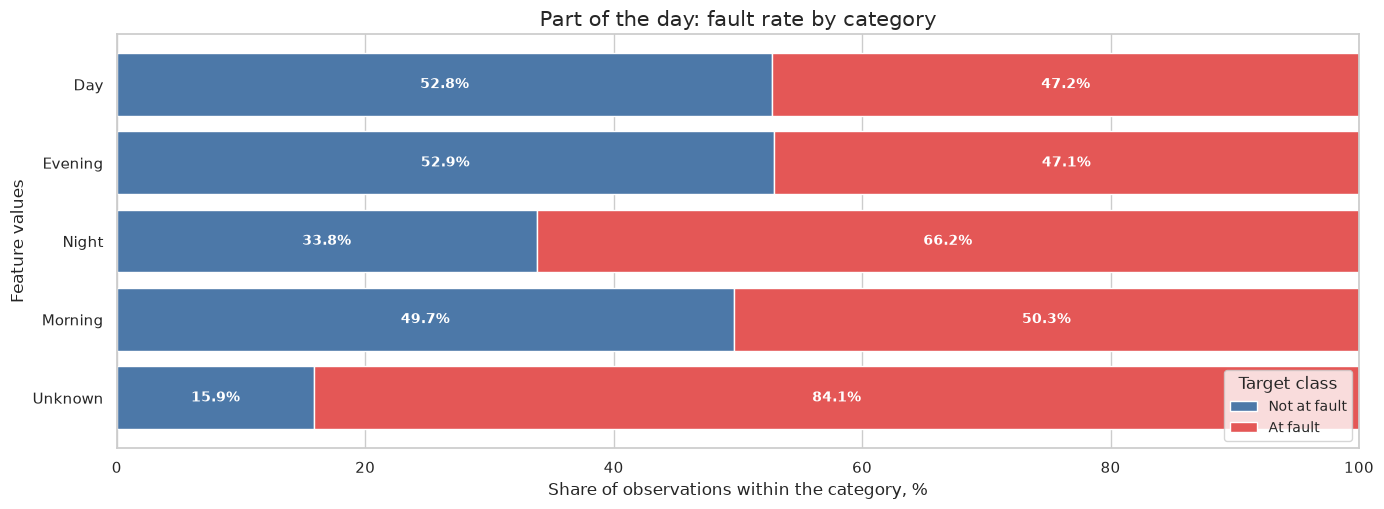

In [26]:
plot_categorical_by_target(df, 'time_bucket', labels_ru=feature_labels)

Aggregating by part of the day confirms the previous chart: night stands out as the riskiest interval, whereas day and evening are closer to a neutral distribution. Such a feature is convenient because it is easier to explain to the business and is more robust to local spikes in individual hours.

#### 4.2.22. Month

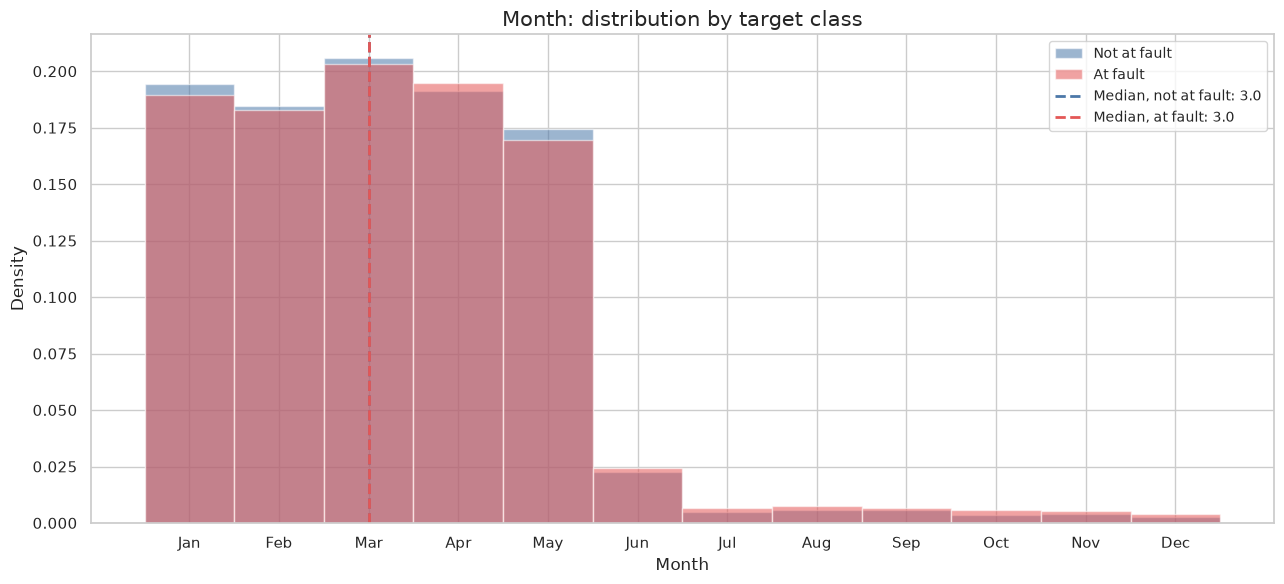

In [27]:
plot_numerical_by_target(
    df,
    'month',
    labels_ru=feature_labels,
    bins=np.arange(0.5, 12.6, 1),
    xticks=np.arange(1, 13),
    xticklabels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
)

There is a calendar effect, but it is weaker than the time-of-day one: at the beginning of the year the classes are almost balanced, while towards the end of the year the share of at-fault parties grows. At the same time, the later months are represented by noticeably fewer observations, so the feature should be treated as supporting context rather than as a primary factor.

#### 4.2.23. Weekend

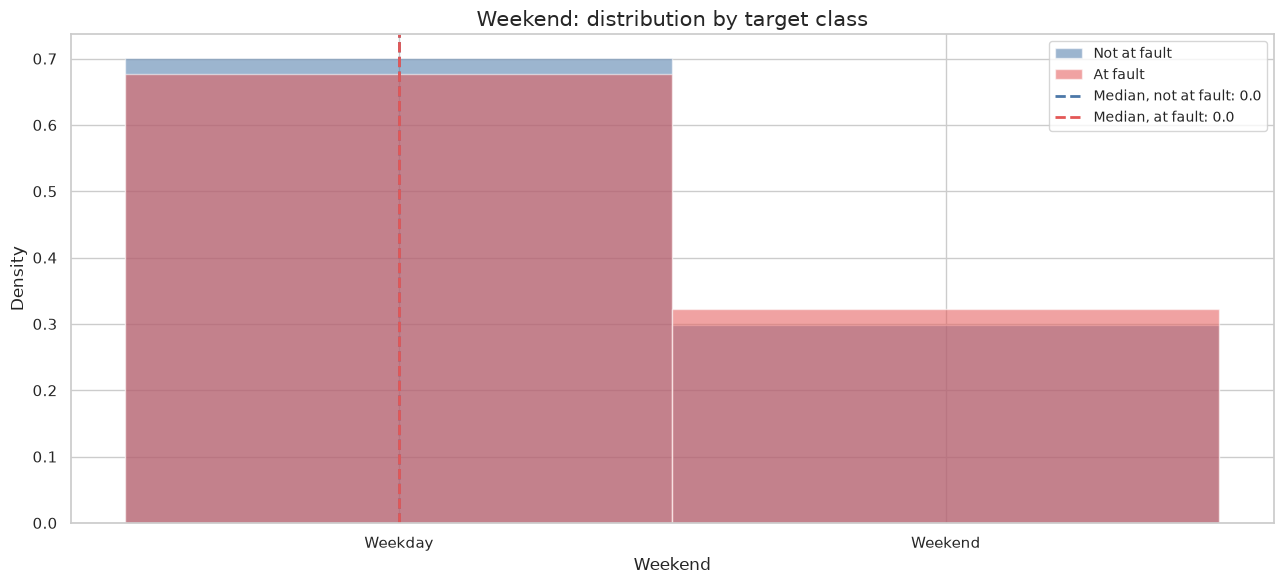

In [28]:
plot_numerical_by_target(
    df,
    'is_weekend',
    labels_ru=feature_labels,
    bins=np.arange(-0.5, 2.0, 1),
    xticks=[0, 1],
    xticklabels=['Weekday', 'Weekend'],
)

At weekends the share of class 1 is slightly higher than on weekdays, but the difference here is moderate. This feature is useful as a cheap background signal: on its own it is weak, but combined with the hour of the trip it helps describe risky scenarios more precisely.

#### 4.2.23. Cellphone use

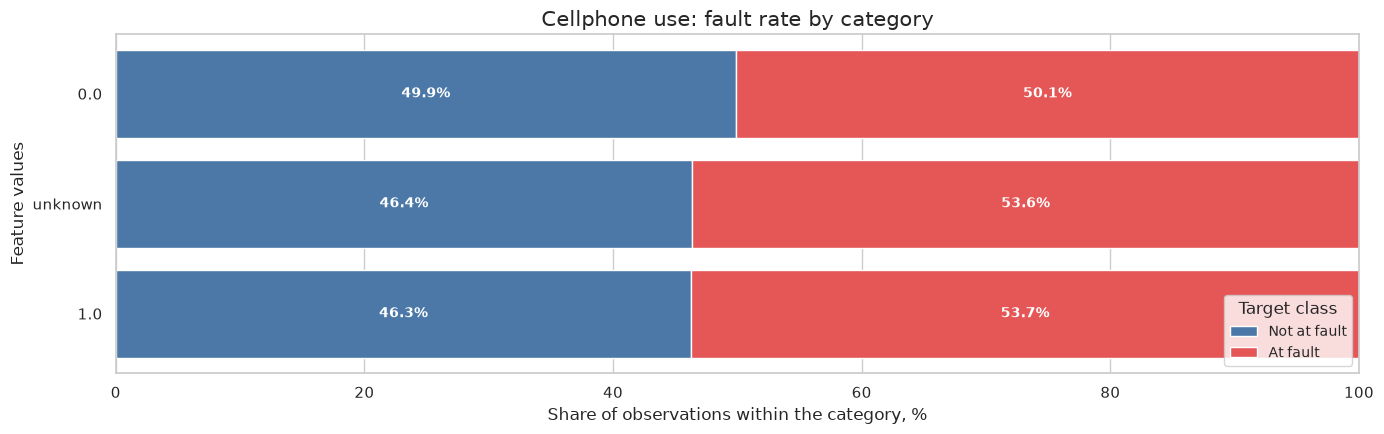

In [29]:
plot_categorical_by_target(df, 'cellphone_in_use', labels_ru=feature_labels)

The `cellphone_in_use` feature is known to the company before the trip, since it knows how its own cars are equipped. The difference between the classes is moderate, but the feature is admissible for the model.

#### 4.2.24. Location type

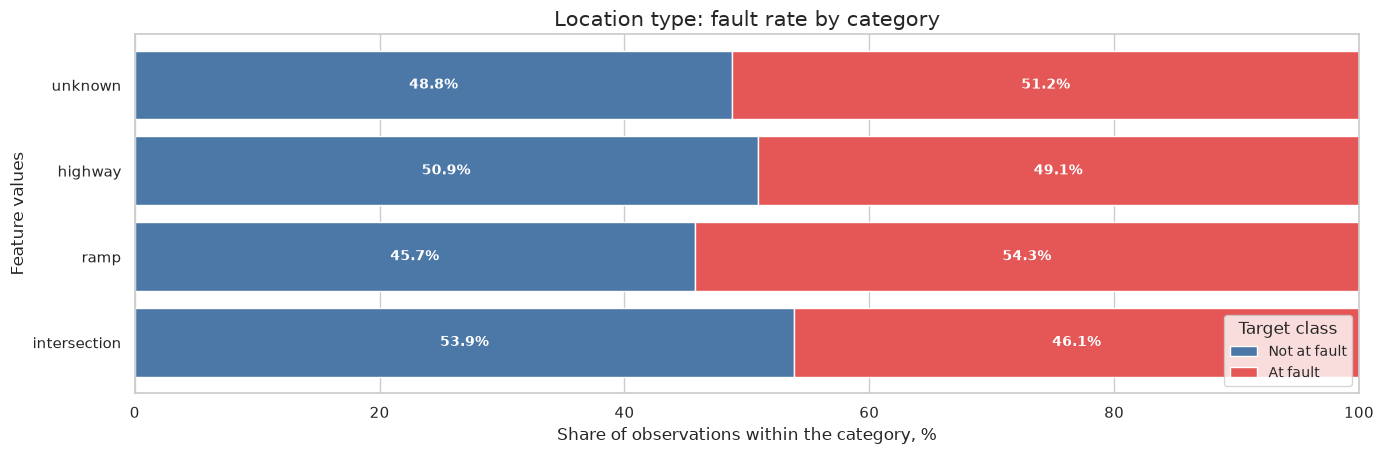

In [30]:
plot_categorical_by_target(df, 'location_type', labels_ru=feature_labels)

The location type (`location_type`) can be computed when the route is planned before the trip. On ramps and highways the share of at-fault parties differs from that at intersections, which is useful for the model.

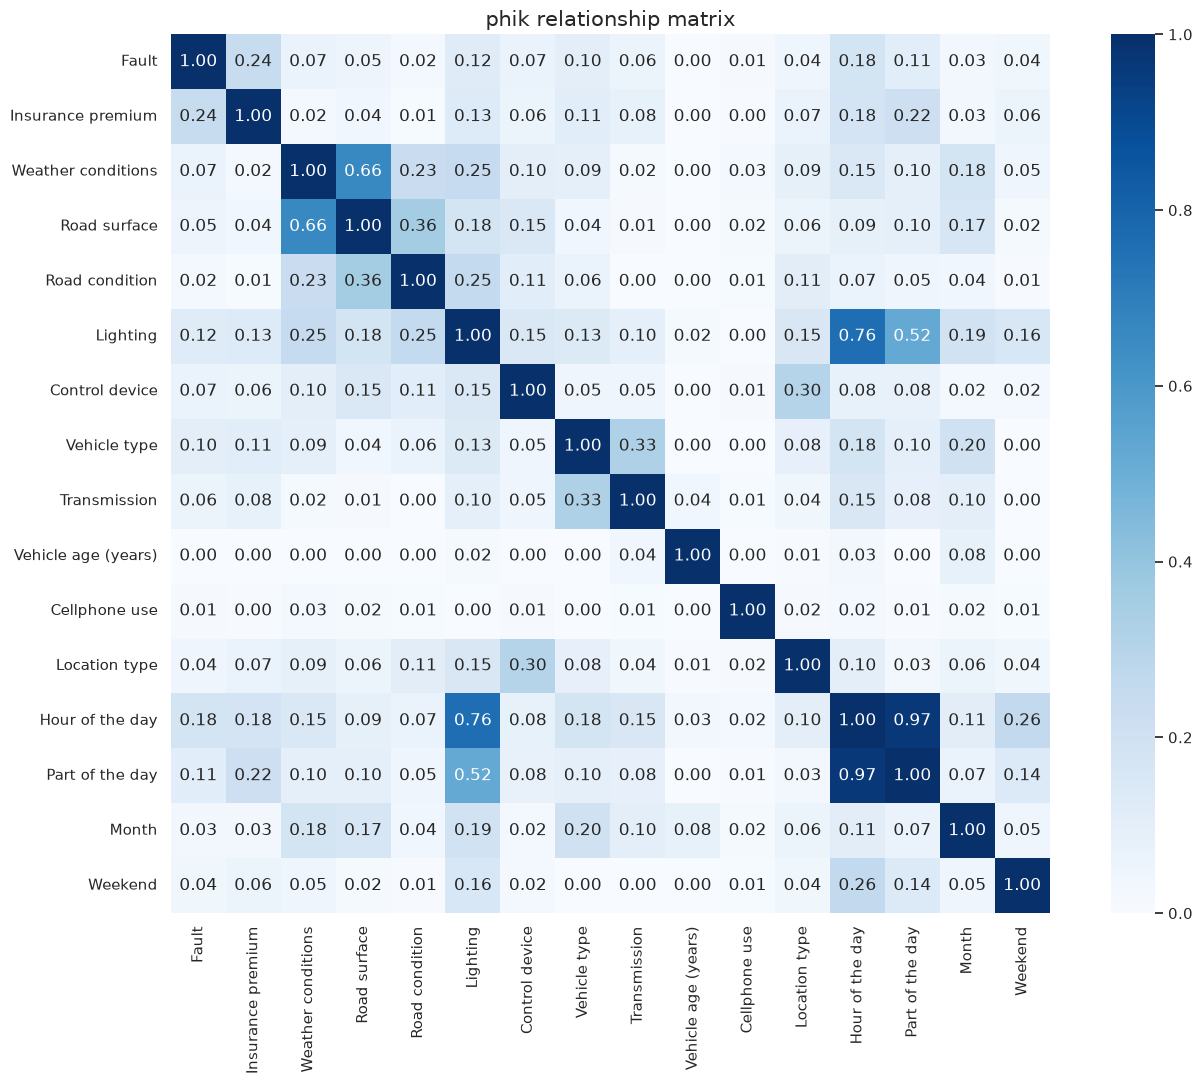

**Strongest relationships with the target**

,phik with the target
Insurance premium,0.243748
Hour of the day,0.183075
Lighting,0.123562
Part of the day,0.110122
Vehicle type,0.097695
Weather conditions,0.068287
Control device,0.067907
Transmission,0.055528
Road surface,0.053600
Location type,0.043787


**Highly multicollinear pairs**

,feature_1,feature_2,phik
0,Lighting,Hour of the day,0.758
1,Hour of the day,Part of the day,0.967


In [31]:
df_for_phik = df[
    [
        "at_fault", "insurance_premium", "weather_1",
        "road_surface", "road_condition_1", "lighting", "control_device",
        "vehicle_type", "vehicle_transmission", "vehicle_age",
        "cellphone_in_use", "location_type",
        "hour_of_day", "time_bucket", "month", "is_weekend",
    ]
].copy()

for col in df_for_phik.columns:
    if col in {"at_fault", "is_weekend"}:
        df_for_phik[col] = df_for_phik[col].astype("Int64").astype("string")
    elif pd.api.types.is_object_dtype(df_for_phik[col]) or pd.api.types.is_string_dtype(df_for_phik[col]) or str(df_for_phik[col].dtype) == "category":
        df_for_phik[col] = df_for_phik[col].astype("string").fillna("unknown")

for col in ["insurance_premium", "vehicle_age", "hour_of_day", "month"]:
    df_for_phik[col] = df_for_phik[col].fillna(df_for_phik[col].median())

phik_matrix = df_for_phik.phik_matrix(
    interval_cols=["insurance_premium", "vehicle_age"]
)
phik_matrix_ru = phik_matrix.rename(index=feature_labels, columns=feature_labels)

target_correlations = (
    phik_matrix["at_fault"].drop("at_fault")
    .sort_values(ascending=False)
    .rename(index=feature_labels)
    .to_frame("phik with the target")
)

multicollinearity_pairs = []
for left_index, left_col in enumerate(phik_matrix.columns):
    for right_col in phik_matrix.columns[left_index + 1:]:
        score = phik_matrix.loc[left_col, right_col]
        if score > 0.7:
            multicollinearity_pairs.append({
                "feature_1": feature_labels.get(left_col, left_col),
                "feature_2": feature_labels.get(right_col, right_col),
                "phik": round(float(score), 3),
            })

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(phik_matrix_ru, annot=True, fmt=".2f", cmap="Blues", ax=ax, square=True, vmin=0, vmax=1)
ax.set_title("phik relationship matrix")
plt.tight_layout()
plt.show()

display(Markdown("**Strongest relationships with the target**"))
display(target_correlations.head(12))
display(Markdown("**Highly multicollinear pairs**"))
display(pd.DataFrame(multicollinearity_pairs))

In [32]:
kept_original_features = [
    'insurance_premium', 'weather_1',
    'road_surface', 'road_condition_1', 'lighting', 'control_device',
    'vehicle_type', 'vehicle_transmission', 'vehicle_age',
    'cellphone_in_use', 'location_type',
]
kept_temporal_features = ['hour_of_day', 'time_bucket', 'month', 'is_weekend']
kept_all_features = kept_original_features + kept_temporal_features

kept_target_correlations = (
    phik_matrix.loc[kept_all_features, 'at_fault']
    .sort_values(ascending=False)
    .rename(index=feature_labels)
    .to_frame('phik with the target')
)

kept_multicollinearity_rows = []
for left_index, left_feature in enumerate(kept_all_features):
    for right_feature in kept_all_features[left_index + 1:]:
        score = float(phik_matrix.loc[left_feature, right_feature])
        if score > 0.7:
            kept_multicollinearity_rows.append({
                'feature_1': feature_labels.get(left_feature, left_feature),
                'feature_2': feature_labels.get(right_feature, right_feature),
                'phik': round(score, 3),
            })

kept_multicollinearity = pd.DataFrame(kept_multicollinearity_rows)
top_kept_features = ', '.join(
    f'`{name}` ({score:.2f})'
    for name, score in kept_target_correlations['phik with the target'].head(6).items()
)

display(Markdown(f'The useful signal is spread across {len(kept_all_features)} features, the most prominent being {top_kept_features}.'))
display(Markdown('**Relationships of the retained features with the target**'))
display(kept_target_correlations.round(3))

if not kept_multicollinearity.empty:
    display(Markdown('**Strong relationships within the retained set**'))
    display(kept_multicollinearity)

The useful signal is spread across 15 features, the most prominent being `Insurance premium` (0.24), `Hour of the day` (0.18), `Lighting` (0.12), `Part of the day` (0.11), `Vehicle type` (0.10), `Weather conditions` (0.07).

**Relationships of the retained features with the target**

,phik with the target
Insurance premium,0.244
Hour of the day,0.183
Lighting,0.124
Part of the day,0.110
Vehicle type,0.098
Weather conditions,0.068
Control device,0.068
Transmission,0.056
Road surface,0.054
Location type,0.044


**Strong relationships within the retained set**

,feature_1,feature_2,phik
0,Lighting,Hour of the day,0.758
1,Hour of the day,Part of the day,0.967


#### 4.3. Final feature set

For modelling we keep 9 original features and 4 time-based ones. The post-event fields were excluded at the SQL query stage.

<div class="alert alert-success">
<b>👍 Success:</b> The data has been explored and processed, everything is ready for training the models!
</div>

#### 4.4. Table for modelling

In [33]:
RANDOM_STATE = 42
FEATURES_CAT = [
    'weather_1', 'road_surface', 'road_condition_1',
    'lighting', 'control_device',
    'vehicle_type', 'vehicle_transmission',
    'cellphone_in_use', 'location_type',
    'time_bucket',
    'hour_of_day', 'month', 'is_weekend',
]
FEATURES_NUM = [
    'insurance_premium', 'vehicle_age',
]
TARGET = 'at_fault'

model_df = df[['case_id', TARGET] + FEATURES_CAT + FEATURES_NUM].copy()

# Cast hour_of_day, month and is_weekend to string so they are treated as categorical
for col in ['hour_of_day', 'month', 'is_weekend']:
    model_df[col] = model_df[col].fillna(-1).astype(int).astype(str)
    model_df.loc[model_df[col] == '-1', col] = np.nan

missing_share = (
    model_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename('missing share')
    .to_frame()
)

display(Markdown(f"**Modelling table size: {model_df.shape[0]:,} rows and {model_df.shape[1]} columns**".replace(",", " ")))
display(model_df.head())
display(missing_share)

**Modelling table size: 56 232 rows and 17 columns**

,case_id,at_fault,weather_1,road_surface,road_condition_1,lighting,control_device,vehicle_type,vehicle_transmission,cellphone_in_use,location_type,time_bucket,hour_of_day,month,is_weekend,insurance_premium,vehicle_age
0,5125160,0,cloudy,dry,other,daylight,none,sedan,auto,0.0,NaN,morning,7,3,0,42.0,2.0
1,5173738,0,clear,dry,normal,daylight,none,sedan,auto,0.0,NaN,day,12,4,0,31.0,5.0
2,5269486,0,clear,dry,normal,daylight,functioning,sedan,auto,0.0,NaN,evening,16,11,0,21.0,1.0
3,5319820,0,clear,dry,normal,dark with street lights,functioning,sedan,auto,0.0,NaN,evening,19,9,0,31.0,4.0
4,5329109,0,clear,dry,normal,daylight,functioning,coupe,auto,0.0,NaN,day,13,11,1,41.0,6.0


,missing share
location_type,0.539017
cellphone_in_use,0.079457
vehicle_age,0.030107
vehicle_transmission,0.015276
insurance_premium,0.009728
road_surface,0.006189
road_condition_1,0.004428
control_device,0.003823
weather_1,0.002988
lighting,0.002739


In [34]:
X = model_df[FEATURES_CAT + FEATURES_NUM].copy()
y = model_df[TARGET].copy()
groups = model_df['case_id'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(model_df, model_df[TARGET], groups=model_df['case_id']))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_train = groups.iloc[train_idx].reset_index(drop=True)
groups_test = groups.iloc[test_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    {
        'sample': ['Training', 'Test'],
        'rows': [len(X_train), len(X_test)],
        'unique cases': [groups_train.nunique(), groups_test.nunique()],
        'share at_fault=1': [
            y_train.mean().round(4),
            y_test.mean().round(4),
        ],
    }
)
display(Markdown("**Data split (80/20 by case_id groups):**"))
display(split_summary)


**Data split (80/20 by case_id groups):**

,sample,rows,unique cases,share at_fault=1
0,Training,45034,35865,0.5049
1,Test,11198,8967,0.5033


<div class="alert alert-danger">
<s><b>😔 Needs fixing:</b> 'hour_of_day', 'month', 'is_weekend' - are categorical features</s>
</div>

The classes in the working set are practically balanced: the shares are close to a 50/50 ratio in both the training and the test part after the 80/20 split. There is therefore no need to balance the classes manually: it would only complicate interpretation and might add unnecessary noise.

#### 4.7. Summary of step 4

Final set: 9 original + 4 time-based features, all available before the trip. The post-event features were excluded at the SQL query stage, and only the complete years in the range starting from 2012 were kept for modelling.


#### 4.5. Preprocessing pipeline

In [35]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), FEATURES_NUM),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first')),
    ]), FEATURES_CAT),
])

display(Markdown("**Categorical features** - missing values filled with the mode"))
display(pd.DataFrame({'feature': FEATURES_CAT}))
display(Markdown("**Numeric features** - missing values filled with the median"))
display(pd.DataFrame({'feature': FEATURES_NUM}))

**Categorical features** - missing values filled with the mode

,feature
0,weather_1
1,road_surface
2,road_condition_1
3,lighting
4,control_device
5,vehicle_type
6,vehicle_transmission
7,cellphone_in_use
8,location_type
9,time_bucket


**Numeric features** - missing values filled with the median

,feature
0,insurance_premium
1,vehicle_age


#### 4.6. Splitting into training and test sets

<div class="alert alert-danger">
<b>😔 Needs fixing V2:</b> The project needs only 2 sets - training and test; a validation set is not needed
</div>

<div class="alert alert-info">
<b>🎓 Student comment:</b> Fixed: the validation set has been removed. The data is split only into a training (80%) and a test (20%) set using GroupShuffleSplit. Hyperparameters are tuned with 5-fold cross-validation on the training set. For the neural network (MLP), early stopping is monitored on an internal holdout carved out of the training part only. The test set is used exactly once — for the final evaluation of the best model in step 6.
</div>

The classes in the working set are practically balanced: the shares are close to a 50/50 ratio in both the training and the test part after the 80/20 split. There is therefore no need to balance the classes manually: it would only complicate interpretation and might add unnecessary noise.

#### 4.7. Summary of step 4

Final set: 9 original + 4 time-based features, all available before the trip. The post-event features were excluded at the SQL query stage, and only the complete years in the range starting from 2012 were kept for modelling.

## Step 5. Modelling

Once the features have been selected, we can move on to building the models. Next we compare three approaches: a linear model as a baseline reference, CatBoost as a more flexible ensemble, and a fully connected neural network as an option capable of capturing non-linear combinations of the driver's state, the weather and road context, the vehicle characteristics and the time of the trip.

#### 5.1. Quality metric

As the main metric we fix `Fβ` with `β = 1.25`. This setting gives roughly a 60/40 balance in favour of recall: for the service it is more important not to miss a risky driver than to cut the number of false alarms at any cost.

The business meaning here is not limited to money. If the system misses a genuinely risky trip, the user ends up in a crash scenario, loses trust in the service and starts to doubt the very idea of safe car sharing. A slight shift towards recall is therefore justified for this task.

<div class="alert alert-success">
<b>👍 Success:</b> An excellent choice of metric!
</div>

In [36]:
warnings.filterwarnings(
    "ignore",
    message=".*'penalty' was deprecated.*",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message=".*Inconsistent values: penalty=.*",
    category=UserWarning,
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

BETA = 1.25
cv_splits = list(GroupKFold(n_splits=5).split(X_train, y_train, groups=groups_train))
model_results = []
model_artifacts = {}
model_predictions = {}

def calc_fbeta(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=BETA, zero_division=0)

def evaluate_scores(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        'f_beta': calc_fbeta(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'y_pred': y_pred,
    }

def add_model_result(model_name, metrics, elapsed_seconds):
    model_results.append(
        {
            'Model': model_name,
            'Fβ (β=1.25)': metrics['f_beta'],
            'ROC-AUC': metrics['roc_auc'],
            'Training time, s': elapsed_seconds,
        }
    )

#### 5.2. Logistic regression and parameter tuning

In [37]:
def objective_logreg(trial):
    C = trial.suggest_float('C', 1e-4, 100.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0) if penalty == 'elasticnet' else None

    model = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', LogisticRegression(
            C=C, penalty=penalty, solver='saga',
            l1_ratio=l1_ratio, max_iter=5000, random_state=RANDOM_STATE,
        )),
    ])

    scores = cross_val_score(model, X_train, y_train, cv=cv_splits, scoring='roc_auc', n_jobs=1)
    return scores.mean()

lr_start = time.perf_counter()
study_lr = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_lr.optimize(objective_logreg, n_trials=20, show_progress_bar=False)

best_lr_params = study_lr.best_params.copy()
best_lr_l1_ratio = best_lr_params.get('l1_ratio') if best_lr_params['penalty'] == 'elasticnet' else None
best_lr_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LogisticRegression(
        C=best_lr_params['C'], penalty=best_lr_params['penalty'], solver='saga',
        l1_ratio=best_lr_l1_ratio, max_iter=5000, random_state=RANDOM_STATE,
    )),
])

lr_cv_fbeta = []
lr_cv_roc_auc = []
for train_fold_idx, val_fold_idx in cv_splits:
    fold_model = clone(best_lr_pipeline)
    fold_model.fit(X_train.iloc[train_fold_idx], y_train.iloc[train_fold_idx])
    fold_proba = fold_model.predict_proba(X_train.iloc[val_fold_idx])[:, 1]
    fold_pred = (fold_proba >= 0.5).astype(int)
    lr_cv_fbeta.append(calc_fbeta(y_train.iloc[val_fold_idx], fold_pred))
    lr_cv_roc_auc.append(roc_auc_score(y_train.iloc[val_fold_idx], fold_proba))

lr_mean_fbeta = np.mean(lr_cv_fbeta)
lr_mean_roc_auc = np.mean(lr_cv_roc_auc)
lr_elapsed = time.perf_counter() - lr_start

model_results.append({
    'Model': 'Logistic regression',
    'Fβ (β=1.25)': lr_mean_fbeta,
    'ROC-AUC': lr_mean_roc_auc,
    'Training time, s': lr_elapsed,
})
model_artifacts['Logistic regression'] = {
    'kind': 'pipeline',
    'pipeline_template': best_lr_pipeline,
    'threshold': 0.5,
}

display(Markdown(f"**Best mean cross-validated ROC-AUC: {lr_mean_roc_auc:.4f}**"))
display(pd.DataFrame([study_lr.best_params]))
display(pd.DataFrame([{
    'Fβ (β=1.25) CV': lr_mean_fbeta,
    'ROC-AUC CV': lr_mean_roc_auc,
    'Time, s': lr_elapsed,
}]).round(4))

**Best mean cross-validated ROC-AUC: 0.6464**

,C,penalty,l1_ratio
0,0.061665,elasticnet,0.663932


,Fβ (β=1.25) CV,ROC-AUC CV,"Time, s"
0,0.5871,0.6464,634.3433


<div class="alert alert-danger">
<s><b>😔 Needs fixing:</b> The test data is not used at this stage (it also needs to be removed from the model training below). Models are compared on the cross-validation metric, and only the single best model is evaluated on the test data</s>
</div>

<div class="alert alert-info"> <b>🎓 Student comment:</b> Fixed: the models are compared by cross-validation, and the test set is used only for the final check of the best model.</div>

Logistic regression sets the baseline quality bar. All metrics are obtained via 5-fold cross-validation.

#### 5.3. CatBoost and parameter tuning

In [38]:
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'loss_function': 'Logloss',
        'random_seed': RANDOM_STATE,
        'verbose': 0,
        'allow_writing_files': False,
    }

    model = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', CatBoostClassifier(**params)),
    ])

    scores = cross_val_score(model, X_train, y_train, cv=cv_splits, scoring='roc_auc', n_jobs=1)
    return scores.mean()

cb_start = time.perf_counter()
study_cb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_cb.optimize(objective_catboost, n_trials=50, show_progress_bar=False)

best_cb_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', CatBoostClassifier(
        iterations=study_cb.best_params['iterations'],
        depth=study_cb.best_params['depth'],
        learning_rate=study_cb.best_params['learning_rate'],
        l2_leaf_reg=study_cb.best_params['l2_leaf_reg'],
        border_count=study_cb.best_params['border_count'],
        loss_function='Logloss', random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    )),
])

cb_cv_fbeta = []
cb_cv_roc_auc = []
for train_fold_idx, val_fold_idx in cv_splits:
    fold_model = clone(best_cb_pipeline)
    fold_model.fit(X_train.iloc[train_fold_idx], y_train.iloc[train_fold_idx])
    fold_proba = fold_model.predict_proba(X_train.iloc[val_fold_idx])[:, 1]
    fold_pred = (fold_proba >= 0.5).astype(int)
    cb_cv_fbeta.append(calc_fbeta(y_train.iloc[val_fold_idx], fold_pred))
    cb_cv_roc_auc.append(roc_auc_score(y_train.iloc[val_fold_idx], fold_proba))

cb_mean_fbeta = np.mean(cb_cv_fbeta)
cb_mean_roc_auc = np.mean(cb_cv_roc_auc)
cb_elapsed = time.perf_counter() - cb_start

model_results.append({
    'Model': 'CatBoost',
    'Fβ (β=1.25)': cb_mean_fbeta,
    'ROC-AUC': cb_mean_roc_auc,
    'Training time, s': cb_elapsed,
})
model_artifacts['CatBoost'] = {
    'kind': 'pipeline',
    'pipeline_template': best_cb_pipeline,
    'threshold': 0.5,
}

display(Markdown(f"**Best mean cross-validated ROC-AUC: {cb_mean_roc_auc:.4f}**"))
display(pd.DataFrame([study_cb.best_params]))
display(pd.DataFrame([{
    'Fβ (β=1.25) CV': cb_mean_fbeta,
    'ROC-AUC CV': cb_mean_roc_auc,
    'Time, s': cb_elapsed,
}]).round(4))

**Best mean cross-validated ROC-AUC: 0.6801**

,iterations,depth,learning_rate,l2_leaf_reg,border_count
0,418,6,0.04069,6.623587,255


,Fβ (β=1.25) CV,ROC-AUC CV,"Time, s"
0,0.619,0.6801,517.854


CatBoost is useful here as a check on a more flexible model. All metrics are obtained via 5-fold cross-validation.

#### 5.4. Fully connected neural network in PyTorch

For the neural network we test five architectures fixed in advance. Early stopping is monitored on an internal validation part carved out of the training set only. The external test set therefore remains completely untouched until the final evaluation of the best model.

For early stopping we use an **exponential moving average (EMA)** of the metric on the internal validation part. The EMA tracks the decaying improvement of the model: if over the last 10 epochs the quality gain is less than 1%, training stops. This makes it possible to stop training before overfitting sets in, without losing useful epochs at the early stages.

In [39]:
def _to_dense(arr):
    """Convert sparse to dense if needed."""
    if scipy.sparse.issparse(arr):
        return arr.toarray()
    return arr


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

ARCHITECTURES = [
    {'name': '[128], ReLU', 'layers': [128], 'activation': 'relu'},
    {'name': '[256, 128], ReLU', 'layers': [256, 128], 'activation': 'relu'},
    {'name': '[384, 192, 96], ReLU', 'layers': [384, 192, 96], 'activation': 'relu'},
    {'name': '[256, 128, 64], Swish', 'layers': [256, 128, 64], 'activation': 'silu'},
    {'name': '[320, 160], LeakyReLU', 'layers': [320, 160], 'activation': 'leaky_relu'},
]

inner_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
inner_train_idx, inner_holdout_idx = next(inner_split.split(X_train, y_train, groups=groups_train))
X_train_inner = X_train.iloc[inner_train_idx].reset_index(drop=True)
X_holdout_inner = X_train.iloc[inner_holdout_idx].reset_index(drop=True)
y_train_inner = y_train.iloc[inner_train_idx].reset_index(drop=True)
y_holdout_inner = y_train.iloc[inner_holdout_idx].reset_index(drop=True)


def activation_factory(name):
    if name == 'relu':
        return nn.ReLU()
    if name == 'silu':
        return nn.SiLU()
    return nn.LeakyReLU(negative_slope=0.1)


class TabularMLP(nn.Module):
    def __init__(self, input_dim, layers, activation_name):
        super().__init__()
        blocks = []
        current_dim = input_dim
        for hidden_dim in layers:
            blocks.append(nn.Linear(current_dim, hidden_dim))
            blocks.append(nn.BatchNorm1d(hidden_dim))
            blocks.append(activation_factory(activation_name))
            current_dim = hidden_dim
        blocks.append(nn.Linear(current_dim, 1))
        self.network = nn.Sequential(*blocks)

    def forward(self, values):
        return self.network(values).squeeze(1)


def predict_mlp_probabilities(model, array, batch_size=4096):
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(array), batch_size):
            batch = torch.tensor(array[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(batch)
            outputs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(outputs)


def fit_mlp_trial(params, trial=None, keep_history=True):
    trial_preprocessor = clone(preprocessor)
    X_inner_train_arr = _to_dense(trial_preprocessor.fit_transform(X_train_inner)).astype(np.float32)
    X_inner_holdout_arr = _to_dense(trial_preprocessor.transform(X_holdout_inner)).astype(np.float32)

    train_targets = y_train_inner.to_numpy(dtype=np.float32)
    holdout_targets = y_holdout_inner.to_numpy(dtype=np.float32)

    architecture = ARCHITECTURES[params['architecture_idx']]
    model = TabularMLP(
        input_dim=X_inner_train_arr.shape[1],
        layers=architecture['layers'],
        activation_name=architecture['activation'],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params['learning_rate'],
        weight_decay=params['weight_decay'],
    )
    criterion = nn.BCEWithLogitsLoss()

    train_dataset = TensorDataset(
        torch.tensor(X_inner_train_arr, dtype=torch.float32),
        torch.tensor(train_targets, dtype=torch.float32),
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=params['batch_size'],
        shuffle=True,
        drop_last=False,
    )

    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 1
    best_ema = -np.inf
    ema_metric = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, 301):
        model.train()
        for batch_values, batch_target in train_loader:
            batch_values = batch_values.to(DEVICE)
            batch_target = batch_target.to(DEVICE)
            optimizer.zero_grad()
            logits = model(batch_values)
            loss = criterion(logits, batch_target)
            loss.backward()
            optimizer.step()

        train_prob = predict_mlp_probabilities(model, X_inner_train_arr)
        holdout_prob = predict_mlp_probabilities(model, X_inner_holdout_arr)
        train_pred = (train_prob >= 0.5).astype(int)
        holdout_pred = (holdout_prob >= 0.5).astype(int)
        with torch.no_grad():
            train_logits_full = model(
                torch.tensor(X_inner_train_arr, dtype=torch.float32, device=DEVICE)
            )
            holdout_logits_full = model(
                torch.tensor(X_inner_holdout_arr, dtype=torch.float32, device=DEVICE)
            )
            train_loss = float(
                criterion(
                    train_logits_full,
                    torch.tensor(train_targets, dtype=torch.float32, device=DEVICE),
                ).item()
            )
            holdout_loss = float(
                criterion(
                    holdout_logits_full,
                    torch.tensor(holdout_targets, dtype=torch.float32, device=DEVICE),
                ).item()
            )
        train_fbeta = calc_fbeta(train_targets, train_pred)
        holdout_fbeta = calc_fbeta(holdout_targets, holdout_pred)

        ema_metric = holdout_fbeta if ema_metric is None else 0.2 * holdout_fbeta + 0.8 * ema_metric
        history.append(
            {
                'epoch': epoch,
                'train_fbeta': train_fbeta,
                'holdout_fbeta': holdout_fbeta,
                'train_loss': train_loss,
                'holdout_loss': holdout_loss,
                'ema_holdout_fbeta': ema_metric,
            }
        )

        if ema_metric > best_ema * 1.01 if best_ema > 0 else ema_metric > best_ema:
            best_ema = ema_metric
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if trial is not None:
            trial.report(float(ema_metric), step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if epochs_without_improvement >= 10:
            break

    model.load_state_dict(best_state)
    holdout_prob = predict_mlp_probabilities(model, X_inner_holdout_arr)
    holdout_metrics = evaluate_scores(holdout_targets, holdout_prob)

    return {
        'history': history if keep_history else None,
        'best_epoch': best_epoch,
        'best_ema': float(best_ema),
        'holdout_fbeta': float(holdout_metrics['f_beta']),
        'holdout_roc_auc': float(holdout_metrics['roc_auc']),
        'architecture_name': architecture['name'],
        'params': params,
    }

In [40]:
mlp_trial_runs = {}

def objective_mlp(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128, 256]),
        'architecture_idx': trial.suggest_categorical('architecture_idx', [0, 1, 2, 3, 4]),
    }
    trial_result = fit_mlp_trial(params, trial=trial, keep_history=True)
    mlp_trial_runs[trial.number] = trial_result
    return trial_result['best_ema']

mlp_start = time.perf_counter()
study_mlp = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
)
study_mlp.optimize(objective_mlp, n_trials=30, show_progress_bar=False)

best_mlp_params = study_mlp.best_params.copy()
best_mlp_trial = mlp_trial_runs[study_mlp.best_trial.number]
best_mlp_epoch = best_mlp_trial['best_epoch']
mlp_elapsed = time.perf_counter() - mlp_start

model_results.append({
    'Model': 'Fully connected neural network',
    'Fβ (β=1.25)': best_mlp_trial['holdout_fbeta'],
    'ROC-AUC': best_mlp_trial['holdout_roc_auc'],
    'Training time, s': mlp_elapsed,
})
model_artifacts['Fully connected neural network'] = {
    'kind': 'mlp',
    'best_params': best_mlp_params,
    'best_epoch': best_mlp_epoch,
    'threshold': 0.5,
}

display(Markdown(f"**Best smoothed Fbeta on the validation part: {study_mlp.best_value:.4f}**"))
display(pd.DataFrame([{
    **study_mlp.best_params,
    'architecture': best_mlp_trial['architecture_name'],
    'best number of epochs': best_mlp_epoch,
}]))
display(pd.DataFrame([{
    'Fbeta (beta=1.25) control': best_mlp_trial['holdout_fbeta'],
    'ROC-AUC control': best_mlp_trial['holdout_roc_auc'],
    'Time, s': mlp_elapsed,
}]).round(4))

**Best smoothed Fbeta on the validation part: 0.6386**

,learning_rate,weight_decay,batch_size,architecture_idx,architecture,best number of epochs
0,0.001218,0.000044,32,0,"[128], ReLU",1


,Fbeta (beta=1.25) control,ROC-AUC control,"Time, s"
0,0.6386,0.6604,301.9775


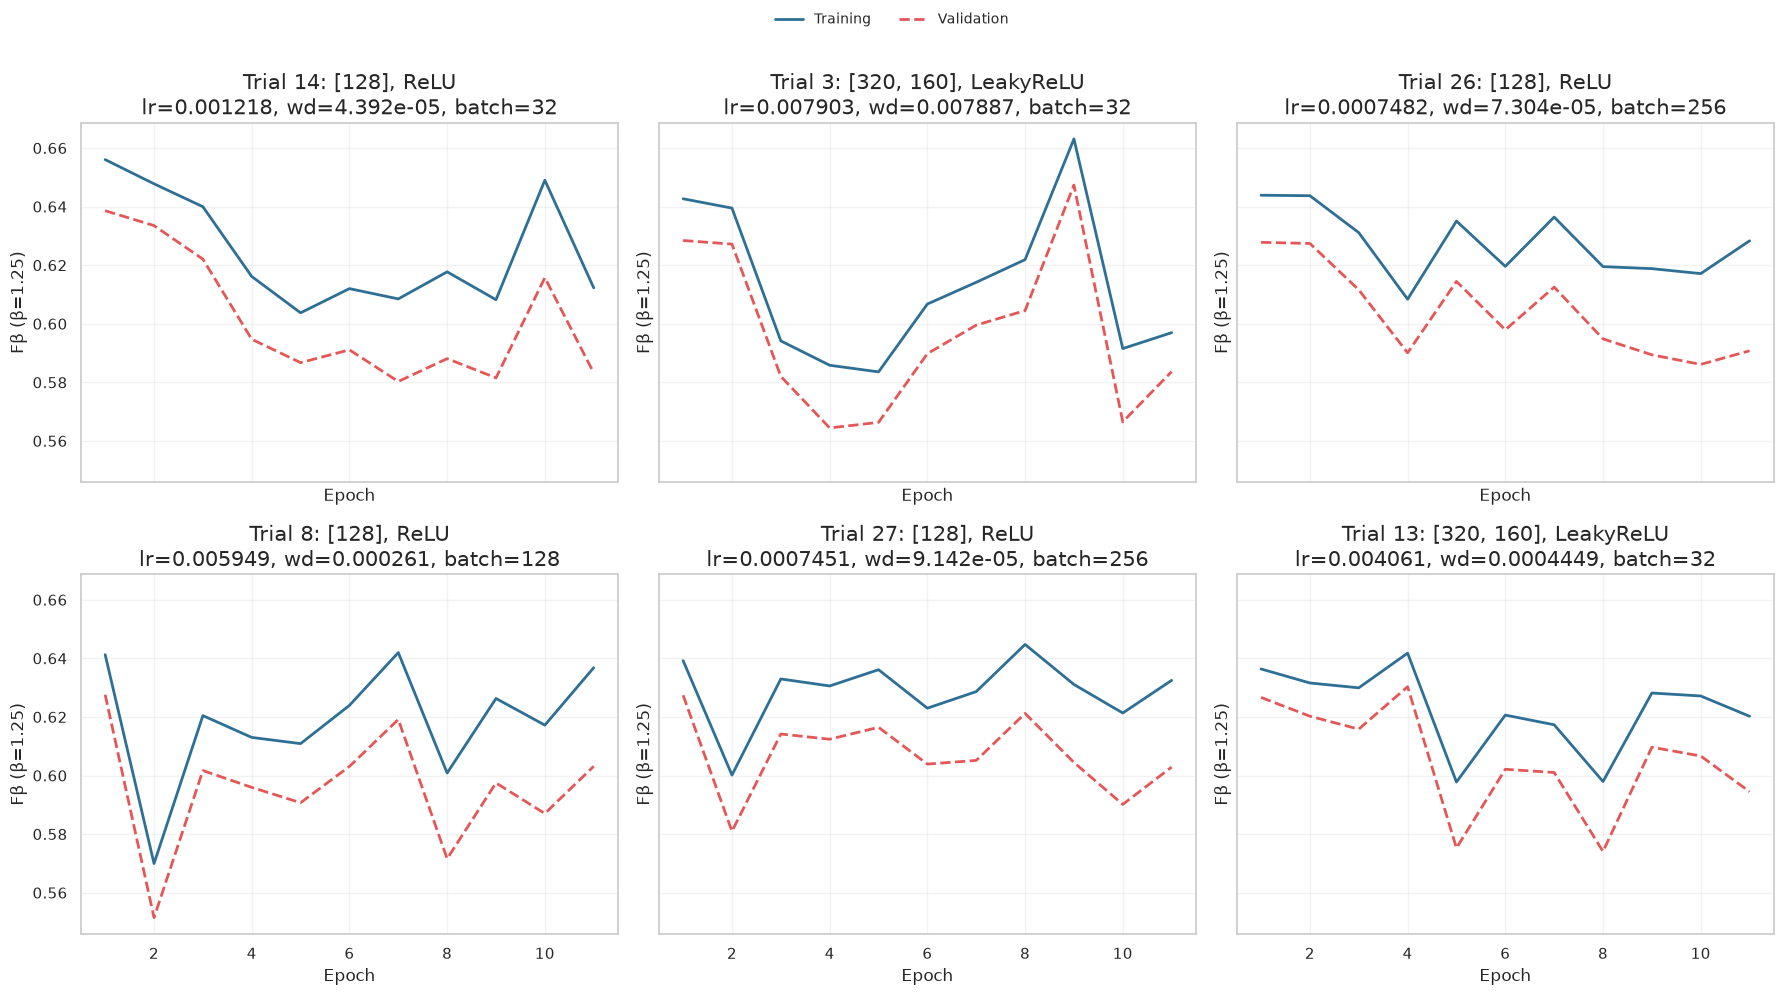

In [41]:
ranked_trials = sorted(
    mlp_trial_runs.items(),
    key=lambda item: item[1]['best_ema'],
    reverse=True,
)[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (trial_number, trial_result) in zip(axes, ranked_trials):
    history_df = pd.DataFrame(trial_result['history'])
    ax.plot(history_df['epoch'], history_df['train_fbeta'], color=MAIN_COLOR, linewidth=2, label='Training')
    ax.plot(history_df['epoch'], history_df['holdout_fbeta'], color='#E45756', linewidth=2, linestyle='--', label='Validation')
    ax.set_title(
        f"Trial {trial_number}: {trial_result['architecture_name']}\n"
        f"lr={trial_result['params']['learning_rate']:.4g}, wd={trial_result['params']['weight_decay']:.4g}, "
        f"batch={trial_result['params']['batch_size']}"
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel(f'Fβ (β={BETA})')
    ax.grid(alpha=0.25)

for ax in axes[len(ranked_trials):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

For the best neural-network runs the quality usually stabilises fairly quickly and then plateaus. This means that early stopping really is appropriate here: additional epochs bring no noticeable gain and only stretch out the training.

#### 5.5. Model comparison

In [42]:
comparison_table = pd.DataFrame(model_results)
comparison_table['Training time'] = comparison_table['Training time, s'].map(lambda value: f'{value:.1f} s')
comparison_table_display = comparison_table[['Model', 'Fβ (β=1.25)', 'ROC-AUC', 'Training time']].copy()
comparison_table_display = comparison_table_display.rename(columns={'Fβ (β=1.25)': 'Fβ (β=1.25) CV', 'ROC-AUC': 'ROC-AUC CV'})
comparison_table_display[['Fβ (β=1.25) CV', 'ROC-AUC CV']] = comparison_table_display[['Fβ (β=1.25) CV', 'ROC-AUC CV']].round(4)
display(comparison_table_display)

,Model,Fβ (β=1.25) CV,ROC-AUC CV,Training time
0,Logistic regression,0.5871,0.6464,634.3 s
1,CatBoost,0.6190,0.6801,517.9 s
2,Fully connected neural network,0.6386,0.6604,302.0 s


Logistic regression and CatBoost are compared by 5-fold cross-validation on the training set, while for the MLP the reference is the internal validation part of train. After that I evaluate the best model on the external test set only.

## Step 6. Evaluating the best model

<div class="alert alert-danger">
    <s><b>😔 Needs fixing:</b> This is where you need to evaluate the best model on the test data</s>
</div>

<div class="alert alert-info"> <b>🎓 Student comment:</b> Fixed: an evaluation of the best model on the test data has been added, with the Fβ reported.</div>

In [43]:
ranked_models = comparison_table.sort_values(
    ['Fβ (β=1.25)', 'ROC-AUC'], ascending=False,
).reset_index(drop=True)

best_model_name = ranked_models.loc[0, 'Model']
best_model_artifact = model_artifacts[best_model_name]

display(Markdown(f"**Best model by cross-validation: {best_model_name}**"))

# Fit the best model on ALL the training data and evaluate it on the test set
if best_model_artifact['kind'] == 'pipeline':
    best_final_model = clone(best_model_artifact['pipeline_template'])
    best_final_model.fit(X_train, y_train)
    best_scores = best_final_model.predict_proba(X_test)[:, 1]
    best_pred = (best_scores >= 0.5).astype(int)
    best_metrics_test = {
        'f_beta': calc_fbeta(y_test, best_pred),
        'roc_auc': roc_auc_score(y_test, best_scores),
    }
    model_artifacts[best_model_name]['fitted_model'] = best_final_model
else:
    # MLP: fit on the full training data
    mlp_params = best_model_artifact['best_params']
    mlp_epochs = best_model_artifact['best_epoch']
    full_preprocessor = clone(preprocessor)
    X_train_full_arr = _to_dense(full_preprocessor.fit_transform(X_train)).astype(np.float32)
    X_test_arr = _to_dense(full_preprocessor.transform(X_test)).astype(np.float32)
    train_targets = y_train.to_numpy(dtype=np.float32)

    architecture = ARCHITECTURES[mlp_params['architecture_idx']]
    mlp_final_model = TabularMLP(
        input_dim=X_train_full_arr.shape[1],
        layers=architecture['layers'],
        activation_name=architecture['activation'],
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        mlp_final_model.parameters(), lr=mlp_params['learning_rate'], weight_decay=mlp_params['weight_decay'],
    )
    criterion = nn.BCEWithLogitsLoss()
    train_dataset = TensorDataset(
        torch.tensor(X_train_full_arr, dtype=torch.float32),
        torch.tensor(train_targets, dtype=torch.float32),
    )
    train_loader = DataLoader(train_dataset, batch_size=mlp_params['batch_size'], shuffle=True, drop_last=False)

    for _ in range(mlp_epochs):
        mlp_final_model.train()
        for batch_values, batch_target in train_loader:
            batch_values = batch_values.to(DEVICE)
            batch_target = batch_target.to(DEVICE)
            optimizer.zero_grad()
            logits = mlp_final_model(batch_values)
            loss = criterion(logits, batch_target)
            loss.backward()
            optimizer.step()

    best_scores = predict_mlp_probabilities(mlp_final_model, X_test_arr)
    best_pred = (best_scores >= 0.5).astype(int)
    best_metrics_test = {
        'f_beta': calc_fbeta(y_test.to_numpy(dtype=np.float32), best_pred),
        'roc_auc': roc_auc_score(y_test.to_numpy(dtype=np.float32), best_scores),
    }
    model_artifacts[best_model_name]['fitted_model'] = mlp_final_model
    model_artifacts[best_model_name]['fitted_preprocessor'] = full_preprocessor

display(Markdown(
    f"**Result on the test set: "
    f"Fβ = {best_metrics_test['f_beta']:.4f}, "
    f"ROC-AUC = {best_metrics_test['roc_auc']:.4f}.**"
))

**Best model by cross-validation: Fully connected neural network**

**Result on the test set: Fβ = 0.5712, ROC-AUC = 0.6661.**

#### 6.1. Confusion matrix

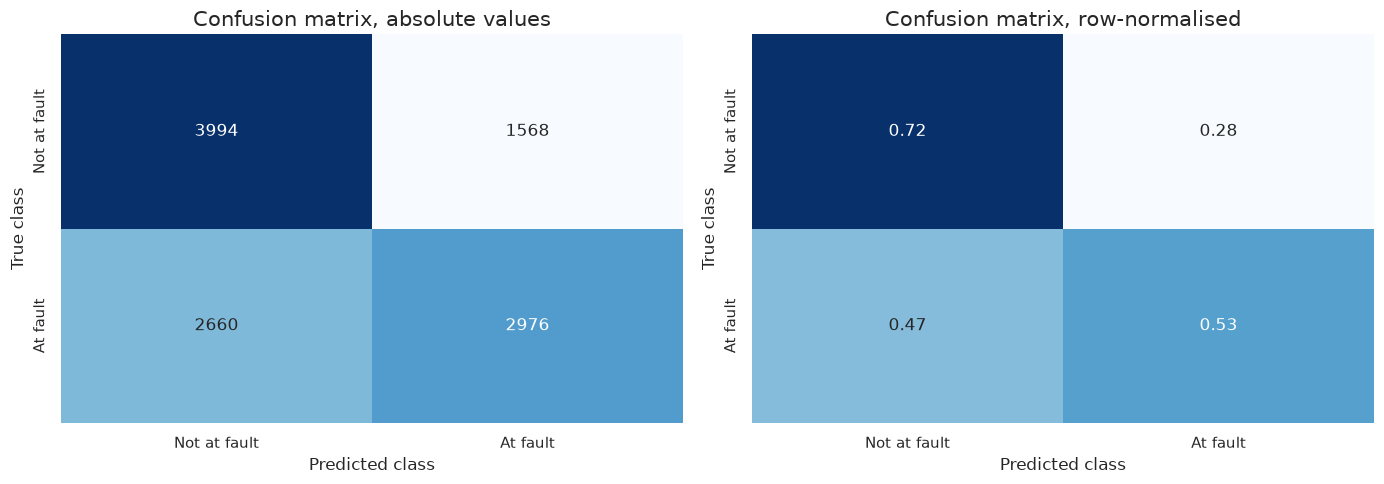

,Fβ (β=1.25),ROC-AUC
0,0.5712,0.6661


In [44]:
conf_counts = confusion_matrix(y_test, best_pred)
conf_norm = confusion_matrix(y_test, best_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    conf_counts,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=['Not at fault', 'At fault'],
    yticklabels=['Not at fault', 'At fault'],
)
axes[0].set_title('Confusion matrix, absolute values')
axes[0].set_xlabel('Predicted class')
axes[0].set_ylabel('True class')

sns.heatmap(
    conf_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    cbar=False,
    ax=axes[1],
    xticklabels=['Not at fault', 'At fault'],
    yticklabels=['Not at fault', 'At fault'],
)
axes[1].set_title('Confusion matrix, row-normalised')
axes[1].set_xlabel('Predicted class')
axes[1].set_ylabel('True class')
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        [
            {
                'Fβ (β=1.25)': best_metrics_test['f_beta'],
                'ROC-AUC': best_metrics_test['roc_auc'],
            }
        ]
    ).round(4)
)

The confusion matrix lets us see the price paid for the final `Fβ`. For the service the bottom-left quadrant matters most: these are the risky drivers that the model missed and did not flag as problematic.

The relatively large number of errors of both types is explained by the difficulty of the task itself: predicting fault in a road accident from admissible features is a problem with high intrinsic uncertainty. Improving the quality further requires expanding the dataset, primarily with telematics and behavioural features that would let the model separate risky scenarios from safe ones more accurately.

<div class="alert alert-success">
<b>👍 Success:</b> Everything is correct!
</div>

#### 6.2. ROC curve

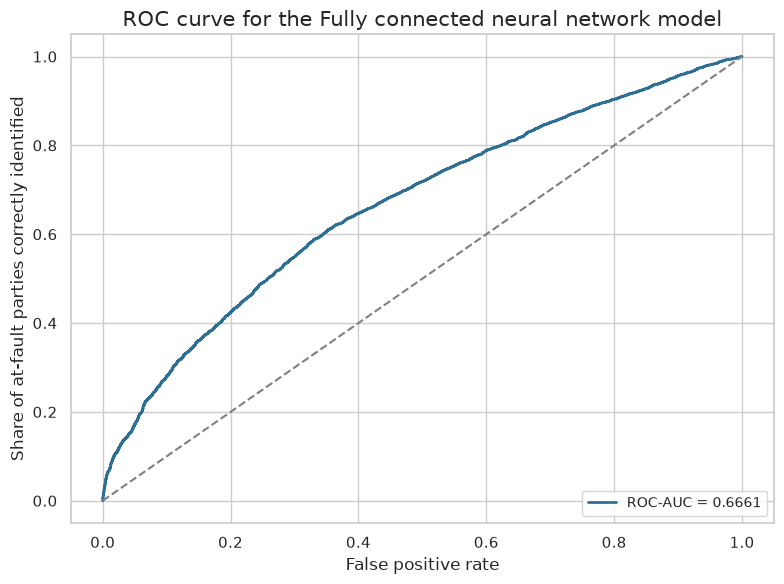

In [45]:
fpr, tpr, _ = roc_curve(y_test, best_scores)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=MAIN_COLOR, linewidth=2, label=f"ROC-AUC = {best_metrics_test['roc_auc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title(f'ROC curve for the {best_model_name} model')
ax.set_xlabel('False positive rate')
ax.set_ylabel('Share of at-fault parties correctly identified')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

The ROC curve shows how well the model is able to rank risk in principle. Even if the operating threshold is later shifted for the sake of higher recall, the shape of this curve answers a more fundamental question: is there any useful ordering of risk in the prediction at all.

The model performs better than a random classifier (the curve lies above the diagonal), but the distance to perfect ranking remains substantial. This confirms that there is a useful signal in the data, but reaching a higher predictive quality will require expanding the feature space with telemetry, driver behaviour data and trip context.

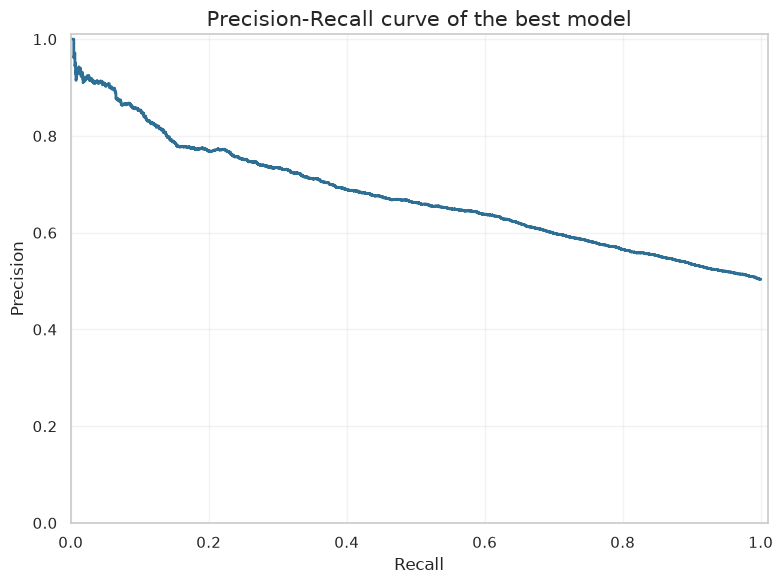

In [46]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, best_scores)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color=MAIN_COLOR, linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve of the best model')
ax.grid(alpha=0.25)
ax.set_xlim([0, 1.01])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.show()

The Precision-Recall curve complements the ROC analysis and is especially useful for assessing quality on balanced data. The shape of the curve shows that the model maintains acceptable precision as recall grows up to a certain threshold, after which precision starts to fall. This confirms that the chosen `Fβ` threshold with its emphasis on recall is a reasonable compromise for a risk-warning task.

#### 6.3. Threshold analysis

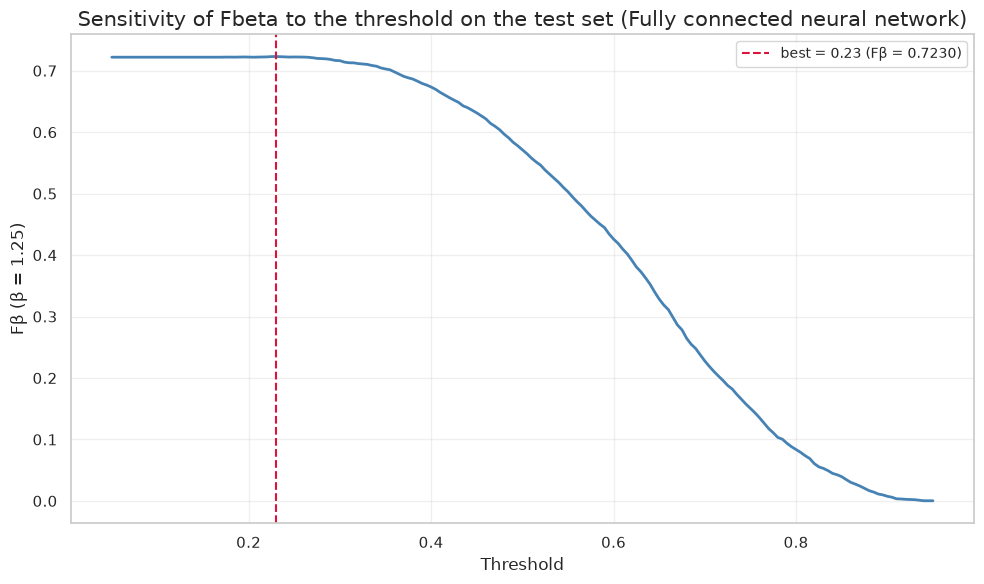

**Fbeta on the test curve peaks at threshold 0.23: Fβ = 0.7230**

In [47]:
# Study how sensitive Fbeta is to the threshold on the test set
thresholds = np.linspace(0.05, 0.95, 181)
threshold_scores = [calc_fbeta(y_test, (best_scores >= threshold).astype(int)) for threshold in thresholds]
best_threshold_idx = int(np.argmax(threshold_scores))
best_threshold = float(thresholds[best_threshold_idx])
best_threshold_fbeta = float(threshold_scores[best_threshold_idx])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, threshold_scores, color='steelblue', lw=2)
ax.axvline(best_threshold, color='crimson', ls='--', lw=1.5,
           label=f'best = {best_threshold:.2f} (Fβ = {best_threshold_fbeta:.4f})')
ax.set_xlabel('Threshold')
ax.set_ylabel(f'Fβ (β = {BETA})')
ax.set_title(f'Sensitivity of Fbeta to the threshold on the test set ({best_model_name})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Fbeta on the test curve peaks at threshold {best_threshold:.2f}: "
    f"Fβ = {best_threshold_fbeta:.4f}**"
))

This chart is needed for the practical tuning of the system. If the business wants to reduce the risk of missing a dangerous trip even further, the threshold can be shifted below 0.50 and this can be deliberately paid for with a larger number of false alarms.

#### 6.4. SHAP analysis

In [48]:
def get_transformed_feature_labels(preprocessor_obj):
    transformed = preprocessor_obj.get_feature_names_out()
    labels = []
    for feature_name in transformed:
        if feature_name.startswith('num__'):
            raw_name = feature_name.split('__', 1)[1]
            labels.append(feature_labels.get(raw_name, raw_name))
            continue
        raw_tail = feature_name.split('__', 1)[1]
        matched_base = next(
            (base_name for base_name in FEATURES_CAT if raw_tail.startswith(base_name + '_')),
            raw_tail,
        )
        value = raw_tail[len(matched_base) + 1:]
        translated_value = feature_value_labels.get(matched_base, {}).get(value, value)
        labels.append(f"{feature_labels.get(matched_base, matched_base)}: {translated_value}")
    return transformed, labels

def transformed_to_raw_name(feature_name):
    if feature_name.startswith('num__'):
        return feature_name.split('__', 1)[1]
    raw_tail = feature_name.split('__', 1)[1]
    for base_name in FEATURES_CAT:
        if raw_tail.startswith(base_name + '_'):
            return base_name
    return raw_tail

def predict_from_transformed_mlp(model, values):
    model_obj = model
    model_obj.eval()
    tensor_values = torch.tensor(values, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        return torch.sigmoid(model_obj(tensor_values)).cpu().numpy()

shap_train_sample = X_train.sample(n=min(300, len(X_train)), random_state=RANDOM_STATE)
shap_test_sample = X_test.sample(n=min(300, len(X_test)), random_state=RANDOM_STATE)

# shap's KernelExplainer/LinearExplainer draw from the global NumPy RNG
np.random.seed(RANDOM_STATE)

if best_model_artifact['kind'] == 'pipeline':
    shap_model = best_model_artifact['fitted_model']
    shap_preprocessor = shap_model.named_steps['preprocessor']
    shap_classifier = shap_model.named_steps['classifier']
    shap_train_array = shap_preprocessor.transform(shap_train_sample)
    shap_test_array = shap_preprocessor.transform(shap_test_sample)
    transformed_feature_names, shap_feature_labels = get_transformed_feature_labels(shap_preprocessor)

    if best_model_name == 'CatBoost':
        shap_explainer = shap.TreeExplainer(shap_classifier)
        shap_values = shap_explainer.shap_values(shap_test_array)
    else:
        shap_explainer = shap.LinearExplainer(shap_classifier, shap_train_array)
        shap_values = shap_explainer.shap_values(shap_test_array)
else:
    shap_preprocessor = best_model_artifact['fitted_preprocessor']
    shap_classifier = best_model_artifact['fitted_model']
    shap_train_array = _to_dense(shap_preprocessor.transform(shap_train_sample)).astype(np.float32)
    shap_test_array = _to_dense(shap_preprocessor.transform(shap_test_sample)).astype(np.float32)
    transformed_feature_names, shap_feature_labels = get_transformed_feature_labels(shap_preprocessor)

    kernel_background = shap_train_array[: min(60, len(shap_train_array))]
    shap_explainer = shap.KernelExplainer(
        lambda values: predict_from_transformed_mlp(shap_classifier, values),
        kernel_background,
    )
    shap_values = shap_explainer.shap_values(
        shap_test_array[: min(120, len(shap_test_array))],
        nsamples=200, silent=True,
    )
    shap_test_array = shap_test_array[: min(120, len(shap_test_array))]

if isinstance(shap_values, list):
    shap_values = shap_values[-1]
shap_values = np.asarray(shap_values)

transformed_importance = pd.DataFrame({
    'feature': shap_feature_labels,
    'raw_feature': [transformed_to_raw_name(name) for name in transformed_feature_names],
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

raw_feature_importance = (
    transformed_importance
    .groupby('raw_feature', as_index=False)['mean_abs_shap']
    .sum()
    .sort_values('mean_abs_shap', ascending=False)
)
raw_feature_importance['feature'] = raw_feature_importance['raw_feature'].map(feature_labels)
top_raw_feature = raw_feature_importance.iloc[0]['raw_feature']
top_transformed_index = int(np.abs(shap_values).mean(axis=0).argmax())

display(raw_feature_importance[['feature', 'mean_abs_shap']].round(4))

,feature,mean_abs_shap
13,Vehicle type,0.0832
3,Insurance premium,0.0572
1,Control device,0.0369
12,Transmission,0.0281
2,Hour of the day,0.0246
10,Part of the day,0.0242
5,Lighting,0.0099
9,Road surface,0.0089
7,Month,0.0071
14,Weather conditions,0.0067


/tmp/ipykernel_3429858/2819385695.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


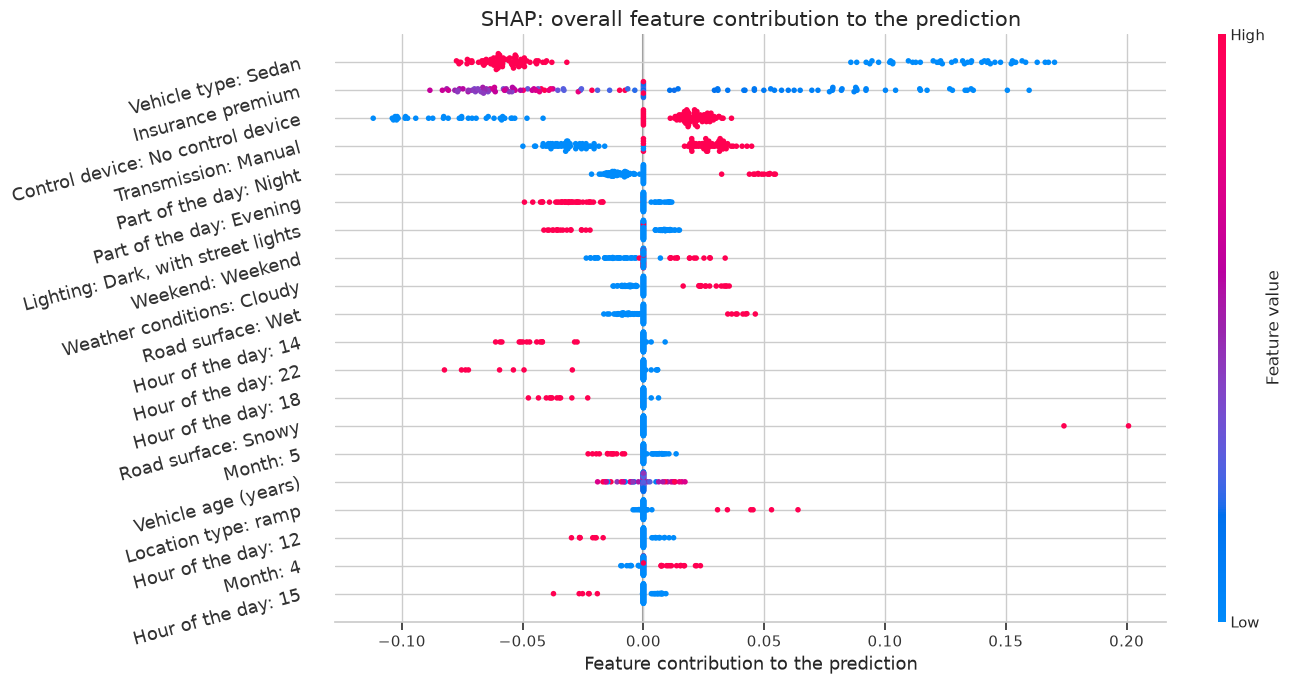

In [49]:
fig, ax = plt.subplots(figsize=(14, 7))
shap.summary_plot(
    shap_values,
    features=shap_test_array,
    feature_names=shap_feature_labels,
    show=False,
)
summary_ax = plt.gca()
summary_ax.set_title('SHAP: overall feature contribution to the prediction')
summary_ax.set_xlabel('Feature contribution to the prediction')
summary_ax.tick_params(axis='y', labelrotation=15)
color_axis = plt.gcf().axes[-1]
color_axis.set_ylabel('Feature value')
plt.gcf().set_size_inches(14, 7)
plt.tight_layout()
plt.show()

The SHAP chart shows which features most often push the prediction up or down. What matters is not only the leader, but the overall structure: if the top places are held by the driver's state, the road context, the vehicle parameters and the time of the trip, then the model really does rely on meaningful signals that are known in advance.

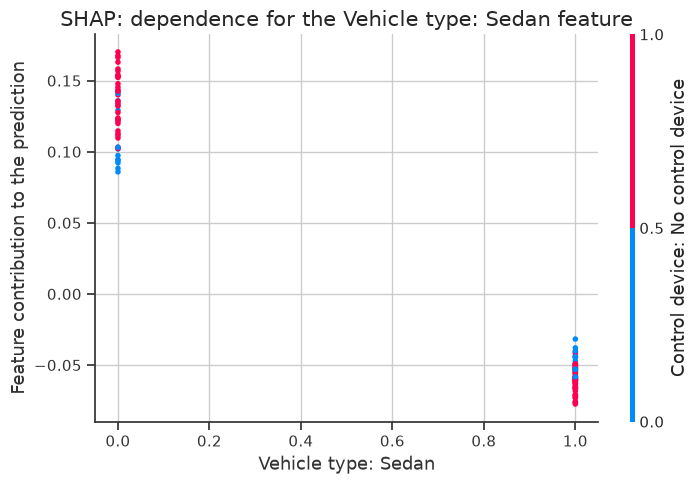

In [50]:
shap.dependence_plot(
    top_transformed_index,
    shap_values,
    shap_test_array,
    feature_names=shap_feature_labels,
    show=False,
)
dependence_ax = plt.gca()
dependence_ax.set_title(f'SHAP: dependence for the {shap_feature_labels[top_transformed_index]} feature')
dependence_ax.set_xlabel(shap_feature_labels[top_transformed_index])
dependence_ax.set_ylabel('Feature contribution to the prediction')
plt.tight_layout()
plt.show()

The dependence plot is needed in order to see not just the importance but the shape of the effect. For the service this is especially useful: it makes it possible to understand where a feature's influence is almost linear and where risk spikes sharply only in particular regimes, for example at night or with clear signs of intoxication.

<div class="alert alert-success">
<b>👍 Success:</b> Everything is correct!
</div>

#### 6.5. Breakdown of the key factor

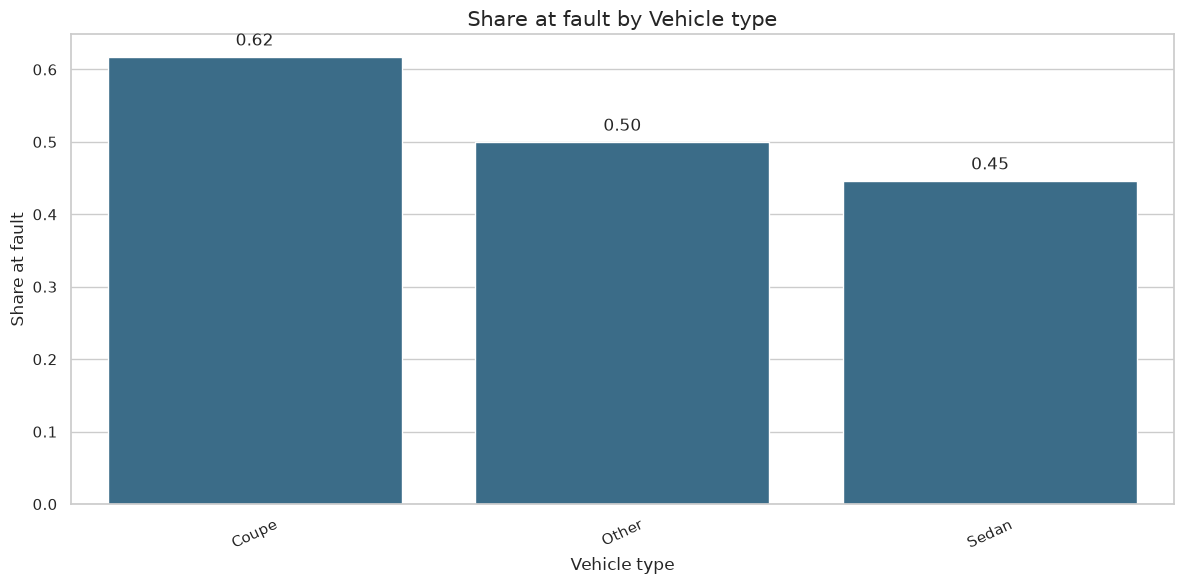

In [51]:
if top_raw_feature in FEATURES_CAT:
    factor_frame = (
        model_df[[top_raw_feature, TARGET]]
        .assign(**{top_raw_feature: model_df[top_raw_feature].astype('string').fillna('missing')})
        .groupby(top_raw_feature, dropna=False)[TARGET]
        .agg(['mean', 'count'])
        .sort_values('mean', ascending=False)
        .reset_index()
    )
    factor_frame['category'] = factor_frame[top_raw_feature].astype(str).map(
        lambda value: feature_value_labels.get(top_raw_feature, {}).get(value, value)
    )
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=factor_frame, x='category', y='mean', color=MAIN_COLOR, ax=ax)
    ax.set_title(f'Share at fault by {feature_labels[top_raw_feature]}')
    ax.set_xlabel(feature_labels[top_raw_feature])
    ax.set_ylabel('Share at fault')
    ax.tick_params(axis='x', rotation=25)
    for index, value in enumerate(factor_frame['mean']):
        ax.text(index, value + 0.01, f'{value:.2f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
else:
    numeric_frame = model_df[[top_raw_feature, TARGET]].dropna().copy()
    if top_raw_feature == 'insurance_premium':
        numeric_frame['category'] = pd.qcut(
            numeric_frame[top_raw_feature],
            q=min(10, numeric_frame[top_raw_feature].nunique()),
            duplicates='drop',
        ).astype(str)
        factor_frame = (
            numeric_frame
            .groupby('category', sort=False)[TARGET]
            .mean()
            .reset_index()
        )
    elif top_raw_feature in {'vehicle_age'} and numeric_frame[top_raw_feature].nunique() > 20:
        factor_frame = (
            numeric_frame
            .assign(category=(numeric_frame[top_raw_feature] // 2 * 2).astype(int))
            .groupby('category', as_index=False)[TARGET]
            .mean()
            .sort_values('category')
        )
        factor_frame['category'] = factor_frame['category'].map(lambda value: f'{value}-{value + 1}')
    else:
        factor_frame = (
            numeric_frame
            .groupby(top_raw_feature)[TARGET]
            .mean()
            .reset_index()
            .sort_values(top_raw_feature)
        )
        factor_frame['category'] = factor_frame[top_raw_feature].astype(str)

    if top_raw_feature == 'month':
        month_labels = {str(idx): label for idx, label in enumerate(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], start=1)}
        factor_frame['category'] = factor_frame['category'].map(lambda value: month_labels.get(value, value))
    elif top_raw_feature == 'is_weekend':
        factor_frame['category'] = factor_frame['category'].map({'0': 'Weekday', '1': 'Weekend'})

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=factor_frame, x='category', y=TARGET, color=MAIN_COLOR, ax=ax)
    ax.set_title(f'Share at fault by {feature_labels[top_raw_feature]}')
    ax.set_xlabel(feature_labels[top_raw_feature])
    ax.set_ylabel('Share at fault')
    rotation = 0 if top_raw_feature in {'hour_of_day', 'month', 'is_weekend'} else 25
    ax.tick_params(axis='x', rotation=rotation)
    for patch in ax.patches:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + 0.01,
            f'{patch.get_height():.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
        )
    plt.tight_layout()
    plt.show()

**Equipment recommendations depending on the leading risk factor:**

| Leading factor | Recommended equipment and measures |
|---|---|
| Insurance premium | Tariff-based risk scoring as a trigger for enhanced screening |
| Weather conditions | Linking the scoring to a live forecast, speed limits |
| Road surface | Stability telematics, monitoring of sharp manoeuvres |
| Road condition | Route warnings, risk re-assessment |
| Lighting | In-cabin camera with IR illumination, night mode |
| Traffic control device | Accounting for uncontrolled segments of the route |
| Vehicle type | Adapting the restrictions to the body type |
| Transmission | Taking the transmission into account when authorising late-night trips |
| Vehicle age | Technical inspection of the fleet |
| Hour of the day | Night-time risk scoring + fatigue sensors + camera |
| Part of the day | Camera + fatigue monitoring for night trips |
| Month | Visibility and stability sensors |
| Weekend | Enhanced behavioural monitoring: camera, telemetry |

Translating feature importance into an understandable risk profile is what makes practical decisions possible. The greatest effect will come from specific pre-trip checks and from monitoring right inside the car.

<div class="alert alert-success">
<b>👍 Success:</b> Everything is correct!
</div>

## Step 7. Overall conclusion

**The best model.** In the comparison in step 5 the best model turned out to be the **fully connected neural network**: on the internal validation part of the training set it achieved `Fβ = 0.6386`, and on the external test set — `Fβ = 0.5712` and `ROC-AUC = 0.6661`.

**Can a risk assessment system be built?** Yes, as a working supporting layer. The model is noticeably better than random ranking and provides a useful risk signal before the trip even starts, although the quality margin remains moderate.

**On what set of features and data was this obtained?** The model is trained on 9 original and 4 time-based features: the insurance premium, the weather and road context, the vehicle characteristics and the start time of the trip. All post-event features are excluded at the SQL query level. Following the completeness check, only the complete year **2012** was kept for modelling; the incomplete **2013** and **2020** were excluded.

**What else is worth collecting:**
- telemetry of sharp accelerations, braking and turns;
- fatigue features from an in-cabin camera;
- speed relative to the limit;
- sobriety data via an alcohol interlock.

**What equipment to add to the car:**
- an alcohol interlock before the trip starts;
- an in-cabin camera with IR illumination;
- a gaze and drowsiness monitoring module;
- a telematics unit for sharp manoeuvres.

**The main conclusion.** Even with a limited set of features available before the trip, the service gets a working risk signal. The next gain in quality should logically be sought not in complicating the current scheme, but in richer pre-crash data and telemetry.
